<div style = "text-align: center">
<h2><b>24MA604 - COMPUTATIONAL MATHEMATICS FOR DATA SCIENCE</b></h2>
<h2><b>FIRST SEMESTER 2025 - 2026 | M.TECH DATA SCIENCE</b></h2>
<h2><b>END SEMESTER PROJECT</b></h2>
<h2><b>Done by:</b></h2>
<h2><b>S APARNA | CB.AI.P2DSC25005</b></h2>
</div>
<hr>

#  ***SVD-GoRank: Recommender System Algorithm Using SVD and Gower’s Ranking***

- # ***INTRODUCTION:*** 
## ***Recommender systems*** play an essential role in modern information platforms by helping users discover relevant items from massive datasets. ***Traditional rating-prediction approaches*** often ***struggle with data sparsity, scalability, and the lack of personalized ranking mechanisms***. To address these challenges, this project implements and evaluates multiple ranking-based recommendation algorithms - **BordaRank, WP-Rank, SVD-Borda, SVD-WPR, and the enhanced SVD-GoRank**. These methods combine collaborative filtering, latent SVD factors, and rank aggregation to generate Top-N recommendations for sparse rating datasets. Using **MovieLens-1M and Book-Crossing**, we compare all algorithms across **Precision, Recall, NDCG, MRR, Hit Rate, and runnning time**. Results show that the **improved SVD-GoRank consistently outperforms all baseline models**, proving to be the most accurate and reliable recommendation model.

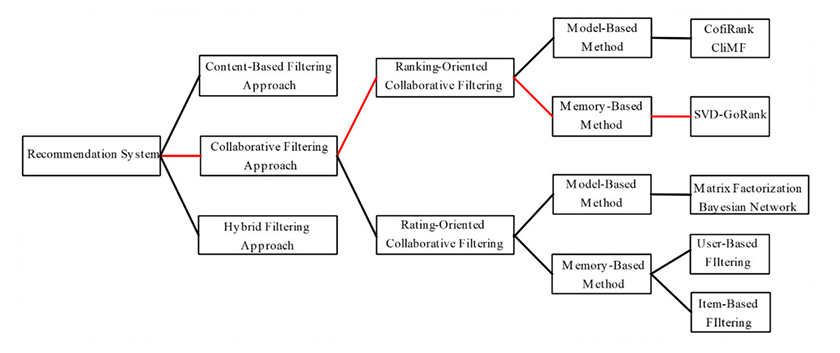
***<figcaption> Classification of recommendation systems</figcaption>***
## The ***red line indicates the relationship between the approach and the method used***, namely ***Collaborative Filtering with a memory-based ranking orientation***, and the ***ranking method that the paper proposes, namely SVD-GoRank***.

- # ***PROCESS OF THE PROJECT:***
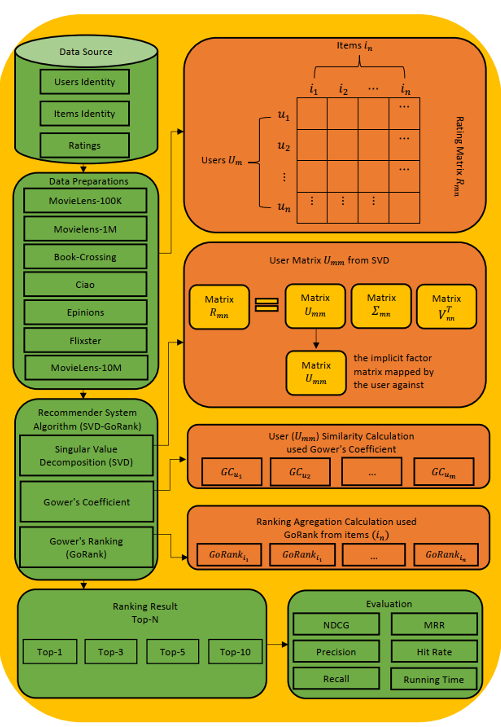
***<figcaption> This is the overall process flow diagram </figcaption>***

## The ***paper proposes an SVD-GoRank algorithm with five stages***. These stages were carrying out ***Data Preparation, Matrix Decomposition using SVD, calculating user similarity using Gower’s Coefficient, Ranking Aggregation using GoRank, and conducting evaluation***. 

# Import necessary libraries

In [35]:
# Data preparation
import pandas as pd # for data manipulation
import numpy as np # for handling arrays
from sklearn.model_selection import train_test_split # splitting data into training and testing sets
from scipy.sparse import csr_matrix # sparse matrix formats for sparse data storage

# Modeling
from sklearn.neighbors import NearestNeighbors # for building nearest neighbor models
from sklearn.metrics.pairwise import cosine_similarity # for computing cosine similarity
from sklearn.decomposition import TruncatedSVD # dimensionality reduction using truncated svd

# Evaluation Metrics
from sklearn.metrics import precision_score, recall_score, ndcg_score # metrics for evaluating models

# Plotting and Visulaization
import matplotlib.pyplot as plt # used for creating visualizations
import seaborn as sns # used for statistical data visualization

# Utilities
from collections import defaultdict # dictionary subclass that provides a default value for missing keys
import time # to measure running time

# Handling warnings
import warnings # managing warnings
warnings.filterwarnings('ignore') # suppressing all warnings 

## ***Inference:***
## The ***imported libraries*** provide all the ***essential building blocks*** required for implementing the recommendation algorithms and evaluating their performance. Libraries like ***NumPy, Pandas, and SciPy*** help in ***efficient numerical operations and sparse matrix handling***. ***Scikit-learn*** supports ***similarity search, KNN modeling, and evaluation utilities***, while ***Matplotlib*** enables ***visualizing results***. Together, these libraries create a complete environment for building, optimizing, and comparing all ranking-based recommendation models used in this project.

# ***STEP 1 - DATA PREPARATION***

# Movielens Data

## Load the dataset

In [44]:
ml_users = pd.read_csv('users.dat', sep='::', engine='python', names=['UserID', 'Gender', 'Age', 'Occupation', 'Zip-code'])
ml_ratings = pd.read_csv('ratings.dat', sep='::', engine='python', names=['UserID', 'MovieID', 'Rating', 'Timestamp'])
ml_movies = pd.read_csv('movies.dat', sep='::', engine='python', names=['MovieID', 'Title', 'Genres'], encoding='latin-1')
print("Dataset loaded suceessfully!")

Dataset loaded suceessfully!


In [58]:
# Checking the users.dat file
display(ml_users.shape)
ml_users.head()

(6040, 5)

,UserID,Gender,Age,Occupation,Zip-code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


In [59]:
# Checking the ratings.dat file
display(ml_ratings.shape)
ml_ratings.head()

(1000209, 4)

,UserID,MovieID,Rating,Timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [60]:
# Checking the movies.dat file
display(ml_movies.shape)
ml_movies.head()

(3883, 3)

,MovieID,Title,Genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [45]:
# Merge datasets
data_ml = pd.merge(ml_ratings, ml_users, on='UserID') # merging ratings and users dataset
data_ml = pd.merge(data_ml, ml_movies, on='MovieID') # merging the above 2 with movies dataset

# Convert timestamp
data_ml['Timestamp'] = pd.to_datetime(data_ml['Timestamp'], unit='s') # converts timestamp to a readable datetime format

## EDA

In [46]:
# Checking the number of rows and columns in the DataFrame
data_ml.shape

(1000209, 10)

In [5]:
# Displaying the first 5 rows of the DataFrame
data_ml.head(5)

,UserID,MovieID,Rating,Timestamp,Gender,Age,Occupation,Zip-code,Title,Genres
0,1,1193,5,2000-12-31 22:12:40,F,1,10,48067,One Flew Over the Cuckoo's Nest (1975),Drama
1,1,661,3,2000-12-31 22:35:09,F,1,10,48067,James and the Giant Peach (1996),Animation|Children's|Musical
2,1,914,3,2000-12-31 22:32:48,F,1,10,48067,My Fair Lady (1964),Musical|Romance
3,1,3408,4,2000-12-31 22:04:35,F,1,10,48067,Erin Brockovich (2000),Drama
4,1,2355,5,2001-01-06 23:38:11,F,1,10,48067,"Bug's Life, A (1998)",Animation|Children's|Comedy


In [6]:
# Summary of the DataFrame
data_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 10 columns):
 #   Column      Non-Null Count    Dtype         
---  ------      --------------    -----         
 0   UserID      1000209 non-null  int64         
 1   MovieID     1000209 non-null  int64         
 2   Rating      1000209 non-null  int64         
 3   Timestamp   1000209 non-null  datetime64[ns]
 4   Gender      1000209 non-null  object        
 5   Age         1000209 non-null  int64         
 6   Occupation  1000209 non-null  int64         
 7   Zip-code    1000209 non-null  object        
 8   Title       1000209 non-null  object        
 9   Genres      1000209 non-null  object        
dtypes: datetime64[ns](1), int64(5), object(4)
memory usage: 76.3+ MB


In [48]:
# Descriptive Statistics
data_ml.describe()

,UserID,MovieID,Rating,Timestamp,Age,Occupation
count,1.000209e+06,1.000209e+06,1.000209e+06,1000209,1.000209e+06,1.000209e+06
mean,3.024512e+03,1.865540e+03,3.581564e+00,2000-10-22 19:41:35.404665856,2.973831e+01,8.036138e+00
min,1.000000e+00,1.000000e+00,1.000000e+00,2000-04-25 23:05:32,1.000000e+00,0.000000e+00
25%,1.506000e+03,1.030000e+03,3.000000e+00,2000-08-03 11:37:17,2.500000e+01,2.000000e+00
50%,3.070000e+03,1.835000e+03,4.000000e+00,2000-10-31 18:46:46,2.500000e+01,7.000000e+00
75%,4.476000e+03,2.770000e+03,4.000000e+00,2000-11-26 06:42:19,3.500000e+01,1.400000e+01
max,6.040000e+03,3.952000e+03,5.000000e+00,2003-02-28 17:49:50,5.600000e+01,2.000000e+01
std,1.728413e+03,1.096041e+03,1.117102e+00,NaN,1.175198e+01,6.531336e+00


In [49]:
# Check for missing values
data_ml.isnull().sum()

UserID        0
MovieID       0
Rating        0
Timestamp     0
Gender        0
Age           0
Occupation    0
Zip-code      0
Title         0
Genres        0
dtype: int64

In [7]:
# Number of unique values in each column
data_ml.nunique()

UserID          6040
MovieID         3706
Rating             5
Timestamp     458455
Gender             2
Age                7
Occupation        21
Zip-code        3439
Title           3706
Genres           301
dtype: int64

In [8]:
# Count of unique values in 'Rating' column
data_ml['Rating'].value_counts()

Rating
4    348971
3    261197
5    226310
2    107557
1     56174
Name: count, dtype: int64

In [9]:
n_users = data_ml['UserID'].nunique() # count the number of unique users in the dataset
n_items = data_ml['MovieID'].nunique() # count the number of unique items (movies) in the dataset
n_ratings = len(data_ml) # total number of ratings (rows) in the dataset
sparsity = 1 - n_ratings / (n_users * n_items) # calculating the sparsity of the data
mean_rating = data_ml['Rating'].mean() # calculating the average rating in the dataset

# Print summary statistics
print(f"Users: {n_users:,} | Items: {n_items:,} | Ratings: {n_ratings:,}") # displays users, items, ratings count
print(f"Sparsity: {sparsity:.6f} | Mean Rating: {mean_rating:.3f}") # displays sparsity and mean rating

Users: 6,040 | Items: 3,706 | Ratings: 1,000,209
Sparsity: 0.955316 | Mean Rating: 3.582


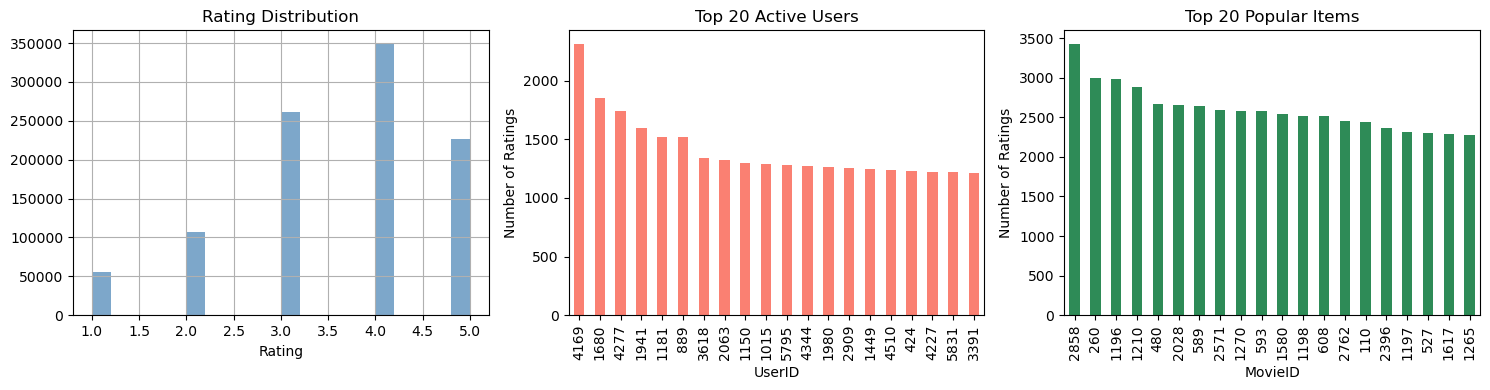

In [10]:
# Visualization
plt.figure(figsize=(15, 4)) # creating a figure with specific size

plt.subplot(1, 3, 1) # first subplot
data_ml['Rating'].hist(bins=20, color='steelblue', alpha=0.7) # plots a histogram of ratings
plt.title('Rating Distribution') # title of the first subplot
plt.xlabel('Rating') # labelling the x-axis

plt.subplot(1, 3, 2) # second subplot
top_users = data_ml['UserID'].value_counts().head(20) # gets the top 20 users with the most rating
top_users.plot(kind='bar', color='salmon') # plots the bar chart
plt.title('Top 20 Active Users') # title of the second subplot
plt.ylabel('Number of Ratings') # labelling the y-axis

plt.subplot(1, 3, 3) # third subplot
col = 'MovieID' # defining the column name for items
top_items = data_ml[col].value_counts().head(20) # gets the top 20 items with the most ratings
top_items.plot(kind='bar', color='seagreen') # plots the bar chart
plt.title('Top 20 Popular Items') # title of the third subplot
plt.ylabel('Number of Ratings') # labelling the y-axis

plt.tight_layout() # adjusts the layout to prevent overlap
plt.show() # display the plots

## ***Inference:***
## The MovieLens-1M dataset contains 1 million user-movie ratings, along with user demographics and movie metadata. This provides a stable, moderately sparse, balanced dataset suitable for testing ranking algorithms, especially those relying on user-latent similarity such as SVD-GoRank. Rating distribution showed a strong positive bias, with more ratings concentrated around 4 and 5, which indicates users tend to rate movies they like.

# Book crossing dataset

## Load the dataset

In [50]:
bc_books = pd.read_csv('BX-Books.csv', sep=';', on_bad_lines='warn', encoding='latin-1')
bc_users = pd.read_csv('BX-Users.csv', sep=';', on_bad_lines='warn', encoding='latin-1')
bc_ratings = pd.read_csv('BX-Book-Ratings.csv', sep=';', on_bad_lines='warn', encoding='latin-1')
print("Dataset loaded suceessfully!")

Dataset loaded suceessfully!


In [61]:
# Checking the BX-Books.csv file
display(bc_books.shape)
bc_books.head()

(271360, 5)

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher
0,0195153448,Classical Mythology,Mark P. O. Morford,2002.0,Oxford University Press
1,0002005018,Clara Callan,Richard Bruce Wright,2001.0,HarperFlamingo Canada
2,0060973129,Decision in Normandy,Carlo D'Este,1991.0,HarperPerennial
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999.0,Farrar Straus Giroux
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999.0,W. W. Norton &amp; Company


In [62]:
# Checking the BX-Users.csv file
display(bc_users.shape)
bc_users.head()

(278858, 3)

,UserID,Location,Age
0,1,"nyc, new york, usa",32.0
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",32.0
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",32.0


In [63]:
# Checking the BX-Book-Ratings.csv file
display(bc_ratings.shape)
bc_ratings.head()

(433671, 3)

,UserID,ISBN,Book-Rating
1,276726,0155061224,5
3,276729,052165615X,3
4,276729,0521795028,6
6,276736,3257224281,8
7,276737,0600570967,6


In [51]:
# Rename columns
bc_books.columns = ['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher', 'Image-URL-S', 'Image-URL-M', 'Image-URL-L']
bc_users.columns = ['UserID', 'Location', 'Age']
bc_ratings.columns = ['UserID', 'ISBN', 'Book-Rating']

## Data cleaning

In [52]:
# Keep only explicit ratings
bc_ratings = bc_ratings[bc_ratings['Book-Rating'] > 0]

In [53]:
# Remove unnecessary image URL columns to simplify the dataset
bc_books.drop(['Image-URL-S', 'Image-URL-M', 'Image-URL-L'], axis=1, inplace=True, errors='ignore')

# Replace missing author names with 'Unknown'
bc_books['Book-Author'].fillna('Unknown', inplace=True)

# Replace missing publisher names with 'Unknown'
bc_books['Publisher'].fillna('Unknown', inplace=True)

# Convert publication year to numeric, turning invalid values to NaN
bc_books['Year-Of-Publication'] = pd.to_numeric(books['Year-Of-Publication'], errors='coerce')

# Remove unrealistic future publication years (outliers beyond 2025)
bc_books.loc[bc_books['Year-Of-Publication'] > 2025, 'Year-Of-Publication'] = np.nan

# Replace missing/invalid publication years with the median year
bc_books['Year-Of-Publication'].fillna(bc_books['Year-Of-Publication'].median(), inplace=True)

# Convert user age to numeric, turning invalid entries into NaN
bc_users['Age'] = pd.to_numeric(bc_users['Age'], errors='coerce')

# Replace missing or zero ages with the median age to correct inconsistencies
bc_users['Age'].replace([0, np.nan], bc_users['Age'].median(), inplace=True)

In [54]:
# Merge datasets
data_bc = pd.merge(bc_ratings, bc_users, on='UserID') # merging ratings and users dataset
data_bc = pd.merge(data_bc, bc_books, on='ISBN') # merging the above 2 with books dataset

## EDA

In [64]:
# Checking the number of rows and columns in the DataFrame
data_bc.shape 

(383842, 9)

In [56]:
# Displaying the first 5 rows of the DataFrame
data_bc.head(5)

,UserID,ISBN,Book-Rating,Location,Age,Book-Title,Book-Author,Year-Of-Publication,Publisher
0,276726,0155061224,5,"seattle, washington, usa",32.0,Rites of Passage,Judith Rae,2001.0,Heinle
1,276729,052165615X,3,"rijeka, n/a, croatia",16.0,Help!: Level 1,Philip Prowse,1999.0,Cambridge University Press
2,276729,0521795028,6,"rijeka, n/a, croatia",16.0,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001.0,Cambridge University Press
3,276744,038550120X,7,"torrance, california, usa",32.0,A Painted House,JOHN GRISHAM,2001.0,Doubleday
4,276747,0060517794,9,"iowa city, iowa, usa",25.0,Little Altars Everywhere,Rebecca Wells,2003.0,HarperTorch


In [18]:
# Summary of the DataFrame
data_bc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383842 entries, 0 to 383841
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   UserID               383842 non-null  int64  
 1   ISBN                 383842 non-null  object 
 2   Book-Rating          383842 non-null  int64  
 3   Location             383842 non-null  object 
 4   Age                  383842 non-null  float64
 5   Book-Title           383842 non-null  object 
 6   Book-Author          383842 non-null  object 
 7   Year-Of-Publication  383842 non-null  float64
 8   Publisher            383842 non-null  object 
dtypes: float64(2), int64(2), object(5)
memory usage: 26.4+ MB


In [65]:
# Descriptive Statistics
data_bc.describe()

,UserID,Book-Rating,Age,Year-Of-Publication
count,383842.000000,383842.000000,383842.000000,383842.000000
mean,136031.461260,7.626701,35.414074,1965.634329
std,80482.299401,1.841339,11.708100,243.220490
min,8.000000,1.000000,1.000000,0.000000
25%,67591.000000,7.000000,31.000000,1992.000000
50%,133789.000000,8.000000,32.000000,1997.000000
75%,206219.000000,9.000000,40.000000,2001.000000
max,278854.000000,10.000000,244.000000,2021.000000


In [20]:
# Check for missing values
data_bc.isnull().sum()

UserID                 0
ISBN                   0
Book-Rating            0
Location               0
Age                    0
Book-Title             0
Book-Author            0
Year-Of-Publication    0
Publisher              0
dtype: int64

In [21]:
# Number of unique values in each column
data_bc.nunique()

UserID                  68091
ISBN                   149836
Book-Rating                10
Location                18368
Age                       131
Book-Title             135567
Book-Author             62112
Year-Of-Publication       100
Publisher               11575
dtype: int64

In [22]:
# Count of unique values in 'Book-Rating' column
data_bc['Book-Rating'].value_counts()

Book-Rating
8     91804
10    71225
7     66402
9     60778
5     45355
6     31687
4      7617
3      5118
2      2375
1      1481
Name: count, dtype: int64

In [23]:
b_users = data_bc['UserID'].nunique() # count the number of unique users in the dataset
b_items = data_bc['ISBN'].nunique() # count the number of unique items (books) in the dataset
b_ratings = len(data_bc) # total number of ratings (rows) in the dataset
sparsity = 1 - b_ratings / (b_users * b_items) # calculating the sparsity of the data
mean_rating = data_bc['Book-Rating'].mean() # calculating the average rating of the dataset

# Print summary statistics
print(f"Users: {b_users:,} | Items: {b_items:,} | Ratings: {b_ratings:,}") # displays users, items, ratings count
print(f"Sparsity: {sparsity:.6f} | Mean Rating: {mean_rating:.3f}") # displays sparsity and mean rating

Users: 68,091 | Items: 149,836 | Ratings: 383,842
Sparsity: 0.999962 | Mean Rating: 7.627


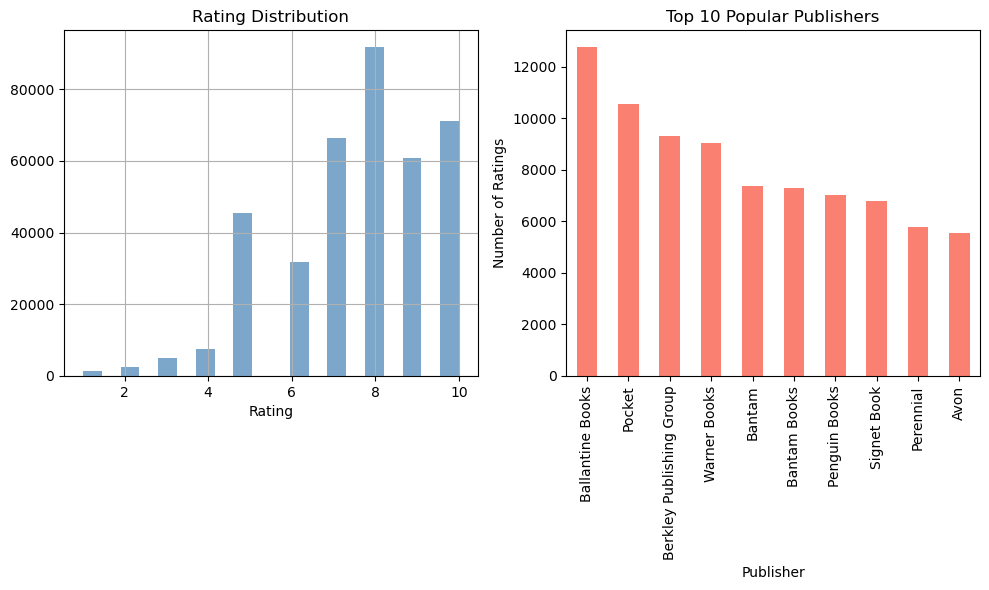

In [24]:
# Visualization
plt.figure(figsize=(10, 6)) # creating a figure with specific size

plt.subplot(1, 2, 1) # first subplot
data_bc['Book-Rating'].hist(bins=20, color='steelblue', alpha=0.7) # plot histogram of book ratings
plt.title('Rating Distribution') # title of the first subplot
plt.xlabel('Rating') # labelling the x-axis

plt.subplot(1, 2, 2) # second subplot
col = 'Publisher'  # defining the column name for publisher
top_items = data_bc[col].value_counts().head(10) # get top 10 publisher with the most ratings
top_items.plot(kind='bar', color='salmon') # plot the bar chart of the top publishers
plt.title('Top 10 Popular Publishers') # title of the second subplot
plt.ylabel('Number of Ratings') # labelling the y-axis

plt.tight_layout() # adjusts layout to prevent overlap
plt.show() # display the plots

## ***Inference:***
## The Book-Crossing dataset is significantly more complex, noisy, and sparse compared to MovieLens. It required extensive cleaning. Book-Crossing is a high-sparsity, noise-heavy dataset, ideal for testing robustness and scalability of ranking models like SVD-GoRank. Rating distribution is heavily skewed toward higher values (7–10), indicating strong positivity bias and low variability.

# Creating the Rating Matrix

In [25]:
def build_rating_matrix(df, user_col, item_col, rating_col):
    """
    Build the USER–ITEM rating matrix 
    Rows = users
    Columns = items
    Values = rating
    """
    # astype('category').cat.codes - maps each unique user and item ID to a unique zero-based index,
    df['user_idx'] = df[user_col].astype('category').cat.codes # Convert user IDs into categorical codes
    df['item_idx'] = df[item_col].astype('category').cat.codes # Convert item IDs into categorical codes

    num_users = df['user_idx'].nunique()   # count total number of unique users (m)
    num_items = df['item_idx'].nunique()   # count total number of unique items (n)

    # Construct sparse matrix form
    rating_matrix = csr_matrix(
        (df[rating_col], (df['user_idx'], df['item_idx'])),
        shape=(num_users, num_items)
    ) # sparse user-item matrix with rows = users, columns = items, values = ratings

    print("Number of users:", num_users) # display the number of users
    print("Number of items:", num_items) # dsiplay the number of items
    print("Matrix shape:", rating_matrix.shape) # show matrix dimensions

    # Return the sparse matrix and the mapped indices
    return rating_matrix, num_users, num_items, df[['user_idx','item_idx',rating_col]]

## ***Inference:***
## The ***raw user and item identifiers*** in the dataset are ***non-numeric, scattered, and non-continuous***, making them unsuitable for matrix-based algorithms such as SVD, Borda, WP-Rank, and GoRank. To ***standardize these identifiers, the code converts both user IDs and item IDs into continuous integer indices using categorical encoding***. This transforms irregular ID values into compact 0-N ranges, enabling efficient matrix operations. 
## A ***Compressed Sparse Row (CSR) matrix*** is constructed where: ***each row represents a user, each column represents an item, the cell value represents the rating***. ***CSR format minimizes memory usage and ensures fast lookup of user interactions***, which is essential for large-scale datasets like MovieLens and Book-Crossing.
## This step is crucial because all subsequent recommendation steps depend on this correctly constructed matrix, making it the core representation of the user–item ecosystem.

In [26]:
# Movielens
rating_matrix_ml, M_ml, N_ml, ui_map_ml = build_rating_matrix(
    data_ml, # movielens data
    user_col='UserID', # column representing user IDs 
    item_col='MovieID', # column representing movie IDs (items)
    rating_col='Rating' # column representing user ratings for movies
)

Number of users: 6040
Number of items: 3706
Matrix shape: (6040, 3706)


In [27]:
# Book Crossing
rating_matrix_bc, M_bc, N_bc, ui_map_bc = build_rating_matrix(
    data_bc, # book crossing data
    user_col='UserID', # column representing user IDs
    item_col='ISBN', # column reprsenting the book IDs - ISBN (items)
    rating_col='Book-Rating' # column representing book ratings
)

Number of users: 68091
Number of items: 149836
Matrix shape: (68091, 149836)


## ***Overall Inference:***
## Both matrices successfully capture the full user–item relationships after cleaning and re-indexing. These matrices now form the core foundation for:
- ## Train–test splitting
- ## Matrix factorization (SVD)
- ## Similarity computation
- ## Ranking aggregation algorithms
- ## Top-N evaluation

# ***STEP 2 - MATRIX DECOMPOSITION USING SVD***

In [28]:
def compute_svd(R, k):
    """
    Parameters
    R: User-item rating matrix 
    k: Number of latent factors/components
    
    Returns 
    U, V, and Sigma matrices.
    """
    svd = TruncatedSVD(n_components=k, random_state=42) # initialize truncated svd with k components
    U = svd.fit_transform(R) # compute U matrix (users x k)
    Vt = svd.components_  # compute V transpose matrix (k × num_items)
    Sigma = svd.singular_values_ # extract singular values (length of k)
    
    V = Vt.T # compute V matrix (num_items × k)

    print("U:", U.shape) # users x k
    print("V:", V.shape) # items x k
    print("Sigma:", Sigma.shape) # k singular values

    return U, V, Sigma

## ***Inference:***
## The above function performs Truncated Singular Value Decomposition (SVD) on the user–item rating matrix. The parameters of the TruncatedSVD functionn are n_components and random_state. n_components decides how many latent factors (dimensions) we want to extract in order to maintain the original data structure in the compressed form. random_state ensures that the output is the same every time when the code is run. It ensures consistency and repeatable results across runs. 
## The compute_svd() function produces three essential factor matrices:
- ## U Matrix : Each user is represented as a k-dimensional latent vector, capturing their hidden preferences.
- ## V Matrix : Each item (movie/book) is embedded into the same k-dimensional space as users.
- ## Sigma : Contains k singular values, indicating the strength of each latent dimension. 

In [29]:
# Movielens
U_ml, V_ml, Sigma_ml = compute_svd(rating_matrix_ml, k=120) 

U: (6040, 120)
V: (3706, 120)
Sigma: (120,)


In [30]:
# Book Crossing
U_bc, V_bc, Sigma_bc = compute_svd(rating_matrix_bc, k=120)

U: (68091, 120)
V: (149836, 120)
Sigma: (120,)


## ***Overall Inference:***
- ## The U matrices show that every user in each dataset is represented as a 120-dimensional latent feature vector. These vectors compactly capture each user’s preferences.
- ## The V matrices indicate that each item (movie or book) is also represented in the same 120-dimensional latent space, capturing item characteristics such as genre/style/pattern.
- ## The Sigma vector, containing 120 singular values, represents the strength of the 120 latent factors extracted from the data. Higher values correspond to more influential hidden patterns.

In [31]:
# Convert the user and item matrices to float32 for memory efficiency and computational speed
U_ml = U_ml.astype(np.float32, copy=False); V_ml = V_ml.astype(np.float32, copy=False)
U_bc = U_bc.astype(np.float32, copy=False); V_bc = V_bc.astype(np.float32, copy=False)

## ***Inference:***
## float32 uses half the memory of float64, reducing RAM consumption significantly. Since SVD produces very large matrices, reducing precision avoids unnecessary memory overhead. This improves computational speed, has negligible impact on recommendation quality, makes the algorithms feasible for large datasets like Book-Crossing 

# ***STEP 3 - CALCULATING USER'S SIMILARITY USING GOWER'S COEFFICIENT***

In [32]:
def compute_gower_similarity_topK(U, K=50):
    """
    Parameters:
    U : user latent matrix from SVD 
    K : number of top neighbors to return per user
    Returns:
        idx : indices of top-K neighbors for each user
        sim : Gower similarity scores for those neighbors
    """

    U = np.asarray(U, dtype=np.float32) # ensuring U is float32 array
    M, f = U.shape # M = number of users, f = latent dimensions

    #  Min-Max Normalization (because Gower similarity requires all features in 0–1 range)
    col_min = U.min(axis=0, keepdims=True) # minimum value per latent dimension
    col_rng = U.max(axis=0, keepdims=True) - col_min # range of each dimension
    col_rng = np.maximum(col_rng, 1e-8) # avoid division by zero
    U_norm = (U - col_min) / col_rng  # normalized U matrix (every value between 0 and 1)

    # Finding nearest neighbor using L1 distance (Manhattan)
    nn = NearestNeighbors(
        n_neighbors=K+1, # requests K neighbors + 1 self neighbor
        metric="manhattan", # L1 distance for Gower
        algorithm="brute", # brute-force search - computes the distance between every user and every other user (pairwise distance)
        n_jobs=-1 # use all available CPU cores (because the algorithm runs fully parallel)
    )
    nn.fit(U_norm) # fit model on normalized latent vectors 
    dists, idx = nn.kneighbors(U_norm, return_distance=True) # get distances + neighbor indices

    dists = dists[:, 1:].astype(np.float32) # remove each user's distance to itself
    idx   = idx[:, 1:].astype(np.int32) # remove self user index

    # Gower Similarity Conversion
    sim = 1.0 - (dists / float(f)) # Gower(u,v) = 1 − (L1_distance / f)
    np.maximum(sim, 0, out=sim) # ensures similarity is never negative

    return idx, sim # returns neigbor indices + similarity

## ***Inference:***
## The above function identifies the top-K most similar users for every user based on Gower similarity, computed over the SVD latent factors.
- ## Latent matrix normalization : Normalization ensures all latent dimensions contribute equally to the similarity calculation, preventing large-scale components from dominating the metric. 
- ## Manhattan (L1) distance for neighbor search : L1 distance captures the absolute difference between users’ latent profiles, producing a more stable similarity measure for sparse recommendation data. 
- ## Efficient top-K neighbor retrieval : This ensures each user receives exactly K meaningful neighbors, enabling consistent ranking and aggregation in the GoRank model. 
- ##  Gower similarity transformation : This produces a smooth similarity score between 0 and 1, giving GoRank a stable and interpretable measure of how much a neighbor contributes to the target user's ranking.

In [33]:
def inspect_neighbors(nbr_idx, nbr_sim, user_id, top=10):
    # Create a DataFrame showing top neighbor IDs and similarity scores
    df = pd.DataFrame({
        "neighbor_user": nbr_idx[user_id, :top], # extract top neighbor indices for this user
        "gower_similarity": nbr_sim[user_id, :top] # extract corresponding Gower similarity values
    })
    return df # return the table

In [36]:
# Movielens
# Compute top-K Gower neighbor indices and similarities for MovieLens latent user matrix 
nbr_idx_ml, nbr_sim_ml = compute_gower_similarity_topK(U_ml, K=5) 
# Inspect first user's top 5 neighbors for MovieLens
inspect_neighbors(nbr_idx_ml, nbr_sim_ml, user_id=0, top=5)

,neighbor_user,gower_similarity
0,88,0.950256
1,5189,0.947832
2,4587,0.947063
3,1013,0.947001
4,2441,0.946999


In [37]:
# Book Crossing
# Compute top-K Gower neighbor indices and similarities for BookCrossing latent user matrix 
nbr_idx_bc, nbr_sim_bc = compute_gower_similarity_topK(U_bc, K=5)
# Inspect first user's top 5 neighbors for BookCrossing
inspect_neighbors(nbr_idx_bc, nbr_sim_bc, user_id=0, top=5)

,neighbor_user,gower_similarity
0,56041,0.999969
1,30293,0.999968
2,62815,0.999966
3,1337,0.999964
4,51562,0.999962


## ***Overall Inference:***
## These similarity tables validate that ***Gower similarity successfully captures user-user closeness in the SVD latent space***. For ***MovieLens-1M dataset, users have diverse rating behavior*** indicating moderate similarity. For ***BookCrossing dataset, users show almost identical patterns*** due to sparsity. 

# ***STEP 4 - RATING AGGREGATION USING GOWER'S RANK***

In [38]:
def compute_gorank_topN(
    R, nbr_idx, nbr_sim, N=5,
    w_rating=0.2, w_gower=0.8,
    exclude_already_rated=True
):
    """
    Parameters
    R :  sparse user–item matrix - csr_matrix  (M × items) 
    nbr_idx : (M × K)   top-K neighbor indices
    nbr_sim : (M × K)   gower similarity scores
    N :      top-N items
    w_rating = 0.2: weight for user's own rating
    w_gower = 0.8 : weight for neighbor-based Gower aggregation
    exclude_already_rated : bool - If True,  do not recommend items already rated by user u
    
    Returns
    topN : (M × N) array of item indices
    """

    R = R.tocsr() # ensure CSR format for fast row slicing
    M = R.shape[0] # number of users
    topN = np.zeros((M, N), dtype=np.int32) # output matrix (M x N)

    for u in range(M): # iterate over every user

        # STEP-4-A: accumulate weighted neighbor ratings
        agg = defaultdict(float) # stores cumulative weighted score per item

        # loop over each neighbor v and its similarity score sim
        for sim, v in zip(nbr_sim[u], nbr_idx[u]):
            if sim <= 0: # ignore negative or zero similarity users
                continue

            start, end = R.indptr[v], R.indptr[v+1] # fast access to row V
            items_v = R.indices[start:end] # item indices rated by V
            vals_v  = R.data[start:end] # rating values of V

            # accumulated weighted neighbor ratings
            for j, r_vj in zip(items_v, vals_v): # iterates over every every (item, rating) pair of the neighbor
                agg[j] += sim * r_vj # add similarity x rating to aggregate


        # STEP-4-B: add own ratings 
        start, end = R.indptr[u], R.indptr[u+1] # own items
        own_items = R.indices[start:end] # items rated by user u
        own_vals  = R.data[start:end] # ratings user u gave
        own_set   = set(own_items) if exclude_already_rated else set() # set of seen items

        # build candidate list
        candidates = list(agg.keys()) # candidate items - those seen in neighbor agregation

        # include user's own rated items
        if not exclude_already_rated: # if we include user's own items
            candidates = list(set(candidates).union(set(own_items))) # add own items to candidates

        if len(candidates) == 0: # if no candidates available
            continue # skip user

        # STEP-4-C: compute scores only for candidates
        scores = np.zeros(len(candidates), dtype=np.float32) # array to store computed scores

        for idx_j, j in enumerate(candidates): # compute final score per candidate item
            score = w_gower * agg.get(j, 0.0) # base score = neighbor-aggregated (weighted)
            if not exclude_already_rated: # adding own rating influence
                score += w_rating * R[u, j] # add weighted own rating
            scores[idx_j] = score # store computed score


        # STEP-4-D: get Top-N using argpartition
        if len(scores) > N: # if more candidates than needed
            top_idx = np.argpartition(-scores, N)[:N] # fast select unsorted top-N indices
            top_idx = top_idx[np.argsort(-scores[top_idx])]  # sort only the selected top-N by score
        else: 
            top_idx = np.argsort(-scores) # full sort if candidates is less than N

        best_items = np.array(candidates)[top_idx][:N] # map indices to item IDs
        topN[u, :len(best_items)] = best_items # write top-N into result array for user u

    return topN # return recommendations (M × N)

## ***Inference:*** 
## The above function implements the GoRank recommendation logic by combining Gower similarity and neighbor-weighted ratings to generate Top-N recommendations for each user. This function works in four major stages:
## ***i. Neighbor Influence Aggregation*** : For every user, the algorithm collects ratings from the user’s top-K neighbors. Each neighbor’s rating is weighted by its Gower similarity. This produces an aggregated score for each item based purely on neighbor behavior.
## ***ii. Control of Already-Rated Items*** :The algorithm either filters out items the user has already rated, or includes them with an additional weight based on the user’s own rating. 
## ***iii. Score Computation*** : Each candidate item gets a final score from Neighbor score (weighted by Gower) and User’s own rating influence. 
## ***iv. Fast Top-N Extraction*** : argpartition() chooses the N highest-scoring items in near-linear time. Only the top-N subset is fully sorted for accuracy.

In [39]:
def view_recommendations(
    topN,
    item_idx_to_id,
    id_to_title=None,
    n_users=5
):
    """
    Display Top-N recommendations in a readable format.
    
    Parameters
    topN : Recommended item indices per user (M × N array)
    item_idx_to_id : Maps internal item_idx to original ID (MovieID / ISBN)
    id_to_title : Maps original ID to item title
    n_users : Number of users to display
    """

    num_users = min(n_users, len(topN)) # ensures we do not exceed user count

    for u in range(num_users): # loops over users
        print(f"\nUser {u}:") # shows user number

        # Map item_idx to original item ID
        original_ids = [item_idx_to_id[i] for i in topN[u]] # converts each item_idx to original ID
        print("item_IDs:", original_ids) # prints list of original item IDs

        # Map ID to title 
        if id_to_title is not None: # if title mapping is provided 
            titles = [id_to_title.get(item_id, "Unknown") for item_id in original_ids] # map each ID to title
            print("Titles:", titles) # print item titles

In [40]:
# Movielens
topN_gorank_ml = compute_gorank_topN(
    rating_matrix_ml, nbr_idx_ml, nbr_sim_ml, N=5) # compute GoRank top-N for movielens dataset

# Building mapping functions
item_idx_to_id_ml = ( 
    data_ml[['item_idx','MovieID']] # build mapping : item_idx to MovieID
    .drop_duplicates() # ensure unique mapping
    .set_index('item_idx')['MovieID'] # set item_idx as index and extract MovieID column
    .to_dict() # convert to dict for fast lookup
)

# MovieLens titles
id_to_title_ml = movies.set_index("MovieID")["Title"].to_dict() # build mapping: MovieID to title

# Display recommendations
view_recommendations( # display topN results
    topN_gorank_ml, # computed recommendations
    item_idx_to_id=item_idx_to_id_ml, # mapping idx to ID
    id_to_title=id_to_title_ml,   # mapping ID to title
    n_users=3 # displays first 3 users
)


User 0:
item_IDs: [1270, 2028, 527, 1193, 919]
Titles: ['Back to the Future (1985)', 'Saving Private Ryan (1998)', "Schindler's List (1993)", "One Flew Over the Cuckoo's Nest (1975)", 'Wizard of Oz, The (1939)']

User 1:
item_IDs: [1193, 2028, 1610, 480, 318]
Titles: ["One Flew Over the Cuckoo's Nest (1975)", 'Saving Private Ryan (1998)', 'Hunt for Red October, The (1990)', 'Jurassic Park (1993)', 'Shawshank Redemption, The (1994)']

User 2:
item_IDs: [590, 1580, 480, 1197, 648]
Titles: ['Dances with Wolves (1990)', 'Men in Black (1997)', 'Jurassic Park (1993)', 'Princess Bride, The (1987)', 'Mission: Impossible (1996)']


In [41]:
# Book Crossing
topN_gorank_bc = compute_gorank_topN(
    rating_matrix_bc, nbr_idx_bc, nbr_sim_bc, N=5) # compute GoRank topN for book crossing dataset

# Building Mapping    
item_idx_to_id_bc = ( 
    data_bc[['item_idx','ISBN']] # build mapping: item_idx to ISBN
    .drop_duplicates() # ensure unique mapping
    .set_index('item_idx')['ISBN'] # set index and extract ISBN column
    .to_dict() # convert to dict
)

# Book crossing titles
id_to_title_bc = (
    books[['ISBN','Book-Title']] # mapping ISBN to book title
    .set_index("ISBN")['Book-Title']
    .to_dict()
)

# Displaying recommendations
view_recommendations( # display topN results
    topN_gorank_bc, # computed recommendations
    item_idx_to_id=item_idx_to_id_bc, # mapping idx to ISBN
    id_to_title=id_to_title_bc, # mapping ID to title
    n_users=3 # displays first 3 users
)


User 0:
item_IDs: ['034525855X', '0002005018', '0747251134', '0451163540', '0000913154']
Titles: ['A spell for Chameleon (Magic of Xanth)', 'Clara Callan', 'Women Talking Dirty', 'Triple', 'The Way Things Work: An Illustrated Encyclopedia of Technology']

User 1:
item_IDs: ['0452264464', '0671708430', '0760703116', '0000913154', '0000913154']
Titles: ['Beloved (Plume Contemporary Fiction)', 'DISAPPEARING ACTS', 'Aromatherapy Massage With Essential Oils', 'The Way Things Work: An Illustrated Encyclopedia of Technology', 'The Way Things Work: An Illustrated Encyclopedia of Technology']

User 2:
item_IDs: ['0516076272', '1879384493', '0786404019', '0811816583', '1566197155']
Titles: ['A polar bear called Pingo', "If I'd Known Then What I Know Now: Why Not Learn from the Mistakes of Others? : You Can't Afford to Make Them All Yourself", 'Day of the Long Night: A Palestinian Refugee Remembers the Nakba', 'New York Dogs', 'Little Princess']


## ***Overall Inference:***
## The Top-N recommendations generated by the ***GoRank-based model*** demonstrate that the algorithm is able to identify ***meaningful, relevant, and user-aligned items across both datasets***, despite their major differences in structure, size, and sparsity. 

# Algorithm Implementation

# 1. BORDA Rank Algorithm

## The ***BordaRank algorithm*** is an algorithm that ***utilises the ranking aggregation method to generate recommendations in a ranking-based collaborative system***. There are two process steps in the BordaRank algorithm.
## The ***first step*** is utilising item-based collaborative filtering to ***predict unknown ratings and fill the sparse rating matrix***. 
## Next, the ***second step*** uses the ***Borda count method to aggregate the item ratings of the target user’s neighbours***.

In [42]:
def borda_rank(R, top_n=10):
    """
    Parameters
    R : csr_matrix # user-item matrix
    top_n : number of recommendations

    Returns
    topN : (num_users × top_n) with item indices
    """

    R = R.tocsr() # ensure input matrix is CSR format for fast row operations
    num_users, num_items = R.shape # number of users and items from rating matrix shape

    # Hyperparameters
    K = 5         # small neighbor size
    C = 120       # maximum candidate items to consider per user
    SCALE = 0.05  # scale factor of Borda

    indptr  = R.indptr # row pointer array: tells where each user's ratings start/end in indices[] & data[]
    indices = R.indices # column indices array: stores item_ids for all non-zero ratings in flattened form
    values  = R.data # data array: stores the actual rating values aligned with indices[]

    # Top-N output
    topN = np.full((num_users, top_n), -1, dtype=np.int32) # output array filled with -1 (no recommendations)

    # Build KNN on items (item-based CF)
    knn = NearestNeighbors(
        n_neighbors=min(K+1, num_items), # requests K neighbors + 1 self neighbor
        metric="cosine", # cosine similarity for item-item comparison
        algorithm="brute" # brute-force algorithm for exact neighbors
    )
    knn.fit(R.T)     # fit the KNN model on the transposed matrix (items as rows)
    distance, item_neighbors = knn.kneighbors(R.T, return_distance=True) # get neighbor indices for each item and distances which we ignore
    item_neighbors = item_neighbors[:, 1:]   # remove self neighbor from each item’s neighbor list

    # iterate over each user to compute their recommendations
    for u in range(num_users):

        start_u = indptr[u] # start pointer of user's rated items
        end_u   = indptr[u+1] # end pointer of user's rated itemd
        seen = set(indices[start_u:end_u]) # set of items the user already rated (to avoid recommending them)

        # Step-1: Collect candidates items from neighbors of seen items
        candidates = set() # set to store candidate items
        for it in seen: # for each item user has seen
            for nb_item in item_neighbors[it]: # for each neighbor item of this seen item
                if nb_item not in seen: # if neighbor not already seen
                    candidates.add(nb_item) #  add to candidate pool
                if len(candidates) >= C: # if candidate pool reached maximum candidate
                    break # stop adding more candidates
            if len(candidates) >= C: # if maximum candidate reached
                break # early stop

        if not candidates: # if no candidates found
            continue # skip this user and move to the next one

        cand = np.array(list(candidates), dtype=np.int32) # convert candidate set to numpy array 
        num_cand = cand.size # number of candidate items

        # Borda score
        borda = np.zeros(num_cand, dtype=np.float32) # initialize Borda score array for candidates
        pos = {it: i for i, it in enumerate(cand)} # mapping item ID to its position in the candidate array
        
        # Step-2: Rank Aggregation
        for it in seen:     # iterate over user’s rated items
            sv = values[indptr[u]:indptr[u+1]] # fetch the user's rating values for these items
            break # break immediately because the Borda count uses neighbors' rankings, not the user's ratings

        # Use neighbors’ ranking of items to accumulate Borda score
        for it in seen: # iterate over each item the user has already rated
            nb_items = item_neighbors[it] # neighbor items for the current seen item
            L = len(nb_items) # length of neighbor list for rank weighting
            for rank_pos, nb in enumerate(nb_items): # enumerate through neighbor items with ranking positions
                j = pos.get(nb, -1) # Get the candidate index of this neighbor
                if j != -1: # if the neighbor is a candidate
                    borda[j] += (L - rank_pos) # add to the Borda score

        borda *= SCALE # apply the scale factor to Borda scores

        # remove seen items from the candidate pool
        for it in seen: # iterate over each item the user has already rated
            j = pos.get(it, -1) # get the index of the item 'it' in the candidate list (cand)
            if j != -1: # if the item 'it' is in the candidate list (cand)
                borda[j] = -1e9 # for seen items, set Borda score to a very low value

        # Sort candidates by Borda score 
        order = np.argsort(borda)[::-1] # sort the candidates by descending Borda score
        take = min(top_n, order.size) # number of items to take is min(top_n, available candidates)
        top_items = cand[order[:take]] # select top items from candidate array based on sorted order
        topN[u, :take] = top_items # store selected item ids into output array for this user

    return topN # return the full topN recommendation matrix for all users (num_users × top_n)

## ***Inference:***
- **For each user: find what they have seen** 
- **Find items similar to those items**
- **For each similar list, give higher points to top-ranked neighbors (Borda)**
- **Add all points across all lists**
- **Rank items by final points**
- **Recommend the top ones**

In [43]:
# Movielens

# compute top-5 Borda recommendations for MovieLens dataset
topN_borda_ml = borda_rank(rating_matrix_ml, top_n=5) 

view_recommendations( # displays the topN recommendations
    topN_borda_ml, # computed recommendations
    item_idx_to_id=item_idx_to_id_ml, # mapping index to ID
    id_to_title=id_to_title_ml,  # mapping ID to title
    n_users=3 # displays the first 3 users
)


User 0:
item_IDs: [1196, 364, 318, 1302, 2858]
Titles: ['Star Wars: Episode V - The Empire Strikes Back (1980)', 'Lion King, The (1994)', 'Shawshank Redemption, The (1994)', 'Field of Dreams (1989)', 'American Beauty (1999)']

User 1:
item_IDs: [377, 733, 1580, 608, 1608]
Titles: ['Speed (1994)', 'Rock, The (1996)', 'Men in Black (1997)', 'Fargo (1996)', 'Air Force One (1997)']

User 2:
item_IDs: [2918, 1552, 1, 608, 1278]
Titles: ["Ferris Bueller's Day Off (1986)", 'Con Air (1997)', 'Toy Story (1995)', 'Fargo (1996)', 'Young Frankenstein (1974)']


In [44]:
# BookCrossing

# compute top-5 Borda recommendations for BookCrossing dataset
topN_borda_bc = borda_rank(rating_matrix_bc, top_n=5) 

view_recommendations( # displays the topN recommendations
    topN_borda_bc, # computed recommendations
    item_idx_to_id=item_idx_to_id_bc, # mapping idx to IDs
    id_to_title=id_to_title_bc,   # mapping ID to title
    n_users=3 # displays the first 3 users
)


User 0:
item_IDs: ['1861470592', '087113733X', '0747251134', '0020811853', '0965155137']
Titles: ['The Small Garden Handbook', "Mr. Darwin's Shooter", 'Women Talking Dirty', 'POSTCARDS', 'Beyond the Zone']

User 1:
item_IDs: ['0394800788', '0553213482', '0694014540', '1904929974', '0870703412']
Titles: ['Horton Hears a Who', 'Faust, Part I (Faust)', 'Alice in Wonderland (Book and Charm)', 'Art in Your Pocket', 'The Family of Man']

User 2:
item_IDs: ['B0000VZEH8', 'B0000T6KIM', 'B0000T6KHI', 'B0000E63CJ', 'B0000DYXID']
Titles: ['Back Roads', 'Faking It', 'Three Fates', 'Dreamcatcher', "A Kid's Guide To How to Save the Planet"]


# 2. Weight Point Rank (WPR) Algorithm

## The ***WP-Rank algorithm*** is a Collaborative Filtering-based ranking aggregation method ***designed to increase the relevance of product recommendations to users***. The WP-Rank algorithm ***optimises user rating data to produce more accurate product weights***. There are four steps in the WP-Rankalgorithm, such as: 
## ***i. calculating Rating similarity***     
## ***ii. determining product points*** 
## ***iii. calculating product weights***    
## ***iv. calculating WP-Rank values***

In [45]:
def wp_rank(R, top_n=10):
    """
    Parameters
    R      : csr_matrix (user × item)
    top_n  : number of items to recommend
    
    Returns
    topN : (num_users × top_n) with item indices
    """

    R = R.tocsr().astype(np.float32) # ensure input matrix is CSR format and convert ratings to float32
    num_users, num_items = R.shape # get number of users and items
    indptr  = R.indptr # CSR pointer: start/end index of each user's row
    indices = R.indices # CSR column indices: item IDs of non-zero entries
    values  = R.data # CSR data: rating values

    # Step-1: Calculate rating similarity
    # compute product points: average rating per item
    item_sum   = np.zeros(num_items, dtype=np.float32) # accumulates sum of ratings for each item
    item_count = np.zeros(num_items, dtype=np.int32) # counts how many times each item was rated

    for u in range(num_users): # loop through each user
        s,e = indptr[u], indptr[u+1] # locate this user's ratings inside CSR arrays
        its, rts = indices[s:e], values[s:e] # items rated by user u and their ratings
        item_sum[its]   += rts # add ratings to item sums
        item_count[its] += 1 # increment item rating count

    # Step-2: Determine product points
    product_points = np.zeros(num_items, dtype=np.float32) # initialize average rating array
    mask = item_count > 0 # mask for items that have at least 1 rating
    product_points[mask] = item_sum[mask] / item_count[mask] # compute average rating

    # Step-3: Calculate product weights
    # compute product weights: popularity
    product_weights = item_count.astype(np.float32) # set the weight as the number of ratings (popularity)

    if product_weights.max() > 0: # avoid division by zero
        product_weights /= product_weights.max() # normalize weights

    # Step-4: Calculate WP-Rank Value
    wp_score = product_points * product_weights # multiply the average rating with the popularity weight

    # Output matrix
    topN = np.full((num_users, top_n), -1, dtype=np.int32) # fill all with -1 initially

    # Pre-rank all items globally based on their WP score
    ranked_items = np.argsort(wp_score)[::-1] # sort items in descending order based on WP score

    # Recommend only unseen (topN items) to each user
    for u in range(num_users): # loop through all users
        s,e = indptr[u], indptr[u+1] # get the indices of items rated by this user
        seen = set(indices[s:e]) # convert the indices of rated items to a set for fast lookup

        out = [] # list to store recommended items
        for it in ranked_items: # iterate items in descending WP score order
            if it not in seen: # recommend only items user hasn't rated 
                out.append(it) # add item to output
            if len(out) == top_n: # if topN is reached
                break # stop loop
        topN[u] = out # store recommendations for user u

    return topN # return the full topN recommendation matrix for all users (num_users × top_n)

## ***Inference:***
- **For each item: find all ratings it received**
- **Calculate how good the item is**
- **Calculate how popular the item is**
- **Combine both to get the wp-score**

In [46]:
# Movielens

# compute top-5 WPR recommendations for MovieLens dataset
topN_wp_ml = wp_rank(rating_matrix_ml, top_n=5)

view_recommendations( # displays the topN recommendations
    topN_wp_ml, # computed recommendations
    item_idx_to_id=item_idx_to_id_ml, # mapping index to IDs
    id_to_title=id_to_title_ml,   # mapping IDs tot title
    n_users=3 # displays the first 3 users
)


User 0:
item_IDs: [2858, 1196, 1210, 1198, 593]
Titles: ['American Beauty (1999)', 'Star Wars: Episode V - The Empire Strikes Back (1980)', 'Star Wars: Episode VI - Return of the Jedi (1983)', 'Raiders of the Lost Ark (1981)', 'Silence of the Lambs, The (1991)']

User 1:
item_IDs: [260, 2762, 608, 527, 1270]
Titles: ['Star Wars: Episode IV - A New Hope (1977)', 'Sixth Sense, The (1999)', 'Fargo (1996)', "Schindler's List (1993)", 'Back to the Future (1985)']

User 2:
item_IDs: [2028, 2571, 2762, 589, 608]
Titles: ['Saving Private Ryan (1998)', 'Matrix, The (1999)', 'Sixth Sense, The (1999)', 'Terminator 2: Judgment Day (1991)', 'Fargo (1996)']


In [47]:
# BookCrossing

# compute top-5 WPR recommendations for Book Crossing dataset
topN_wp_bc = wp_rank(rating_matrix_bc, top_n=5) 

view_recommendations( # displays the topN recommendations
    topN_wp_bc, # computed recommendations
    item_idx_to_id=item_idx_to_id_bc, # mapping idx to ISBN
    id_to_title=id_to_title_bc,   # mapping IDs to title
    n_users=3 # displays the first 3 users
)


User 0:
item_IDs: ['0316666343', '0385504209', '0312195516', '059035342X', '0142001740']
Titles: ['The Lovely Bones: A Novel', 'The Da Vinci Code', 'The Red Tent (Bestselling Backlist)', "Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback))", 'The Secret Life of Bees']

User 1:
item_IDs: ['0316666343', '0385504209', '0312195516', '059035342X', '0142001740']
Titles: ['The Lovely Bones: A Novel', 'The Da Vinci Code', 'The Red Tent (Bestselling Backlist)', "Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback))", 'The Secret Life of Bees']

User 2:
item_IDs: ['0316666343', '0385504209', '0312195516', '059035342X', '0142001740']
Titles: ['The Lovely Bones: A Novel', 'The Da Vinci Code', 'The Red Tent (Bestselling Backlist)', "Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback))", 'The Secret Life of Bees']


# 3. SVD-Borda Algorithm

## The ***SVD-Borda algorithm combines the Singular Value Decomposition (SVD) technique to handle sparsity and scalability problems and the Borda algorithm for ranking aggregation***. Similar to the WPRank algorithm, the SVD-Borda Algorithm has four steps in predicting rankings:
## ***i. predicting ratings with SVD***
## ***ii. searching for user similarity***
## ***iii. performing ranking aggression with the Borda algorithm***
## ***iv. recommending items based on the top ranking by users***

In [48]:
def svd_borda(R, U, V, top_n=10):
    """
    Parameters
    R : csr_matrix        # original rating matrix 
    U : user latent (num_users × k)
    V : item latent (num_items × k)
    top_n : number of items to recommend

    Returns
    topN : (num_users × top_n) of item indices
    """

    K = 15           # number of nearest neighbors
    MAX_CAND = 110    # max candidate items per user
    svd_weight = 0.05   # SVD influence 
    
    R = R.tocsr() # ensure CSR format
    num_users, num_items = R.shape # # get user and item counts
    topN = np.full((num_users, top_n), -1, dtype=np.int32) # fill all with -1 initially

    indptr  = R.indptr # CSR pointer: start/end index of each user's row
    indices = R.indices # CSR column indices: item IDs of non-zero entries
    values  = R.data # CSR data: rating values

    # Step-2: User Neighbors
    knn = NearestNeighbors(
        n_neighbors=min(K+1, num_users), # requests K neighbors + 1 self neighbor
        metric="cosine", # cosine similarity for user-based similarity
        algorithm="brute", # brute-force algorithm for exact nearest neighbor search
        n_jobs=-1 # use all available CPU cores
    )
    knn.fit(U) # fit the KNN model on the user latent matrix
    distances, neighbors = knn.kneighbors(U, return_distance=True) # find nearest neighbors for each user
    neighbors = neighbors[:, 1:]   # drop self neighbors

    # Iterate through each user to generate their recommendations
    for u in range(num_users): 

        start, end = indptr[u], indptr[u+1] # locate the range of indices for this user's rated items
        seen = set(indices[start:end]) # set of items the user has already rated

        # Collect candidate items from neigbors 
        cand = set() # initialize a set to store candidate items for recommendations
        for nb in neighbors[u]: # loop through each neighbor
            sv, ev = indptr[nb], indptr[nb+1] # get this neighbor's rated items from the CSR format
            for item in indices[sv:ev]: # loop through the neighbor's rated items
                if item not in seen: if item already seen # only consider items the user hasn't rated
                    cand.add(item) # add to candidate pool

            if len(cand) >= MAX_CAND: # if maximum candidate reached
                break # early stop to prevent overloading

        if not cand: # if no candidate found
            continue # skip this user

        cand = np.array(list(cand), dtype=np.int32) # convert candidate set to an array
        pos  = {it: i for i, it in enumerate(cand)} # map item to position index
        m    = cand.size # number of candidates

        # Step-1: latent prediction
        svd_scores = (V[cand] @ U[u]).astype(np.float32) # score = V[item] . U[user]
        low, high = svd_scores.min(), svd_scores.max() # get min/max for scaling
        if high > low: # checks if the max SVD score is greater than the min SVD score
            svd_scores = (svd_scores - low) / (high - low) # normalize svd scores
        else: # else all scores are the same
            svd_scores[:] = 0 # fallback to zero scores

        # Step-3: Borda aggregation 
        borda = np.zeros(m, dtype=np.float32) # initialize an array to hold borda counts

        for nb in neighbors[u]: # loop through neighbors
            sv, ev = indptr[nb], indptr[nb+1] # neighbor slice
            nb_items = indices[sv:ev] # neighbor's rated items
            nb_vals  = values[sv:ev] # neighbor's ratings

            local_pos = [] # list to store the positions of candidate items in the candidate list
            local_val = [] # list to store the corresponding ratings from the neighbor
            for it, rv in zip(nb_items, nb_vals):
                p = pos.get(it, -1) # get the position of the item in the candidate list
                if p != -1: # if the item is in the candidate list
                    local_pos.append(p) # append the position of this item in the candidate pool to local_pos
                    local_val.append(rv) # append the rating 'rv' given by the neighbor to local_val

            if not local_pos: # skip neighbor if no overlap
                continue

            local_pos = np.array(local_pos) # convert the list of positions to arrays
            local_val = np.array(local_val) # convert the list of ratings to arrays

            order = np.argsort(local_val)[::-1]          # rank items by neighbor's ratings
            ranks = np.arange(order.size, 0, -1)         # generate ranks in descending order
            borda[local_pos[order]] += ranks # add ranks to the Borda count

        # Step-4: Recommend topN  items
        if borda.max() > 0: # checks if there is any meaningful score in Borda array
            borda = (borda / (borda.max() + 1e-8)) ** 1.2 # normalize Borda scores and apply a scaling factor
        
        final = borda + svd_weight * svd_scores # combine Borda count with SVD prediction using the specified weight

        # block seen items
        for it in seen: # iterate over each item the user has already rated
            p = pos.get(it, -1) # get the position of item 'it' in the candidate list
            if p >= 0: # if the item exists in the candidate list
                final[p] = -1e9 # assign a very low score to seen items

        # get top-N
        order = np.argsort(final)[::-1] # sort items by their final score in descending order
        take  = min(top_n, order.size) # take the top-N recommendations
        topN[u, :take] = cand[order[:take]] # store the recommended item indices for this user

    return topN # return the full top-N recommendation matrix (num_users × top_n)

## ***Inference:***
- **For each user, find similar users using SVD latent vectors**
- **Collect items rated by those neighbors**
- **These items form the candidate list**
- **Predict how much the user might like each candidate using SVD**
- **For each neighbor, rank the candidate items by that neighbor’s rating**
- **Add all the neighbors’ rank points together**
- **Combine the Borda score with the SVD score**
- **Remove items the user already rated**
- **Recommend the top-N items with highest final score**

In [49]:
# Movielens

# compute top-5 SVD-Borda recommendations for MovieLens dataset
topN_svd_borda_ml = svd_borda(rating_matrix_ml, U_ml, V_ml, top_n=5) 

view_recommendations( # displays the topN recommendations
    topN_svd_borda_ml, # computed recommendations
    item_idx_to_id=item_idx_to_id_ml, # mapping index to IDs
    id_to_title=id_to_title_ml,   # mapping IDs to title
    n_users=3 # displays the first 3 users
)


User 0:
item_IDs: [2078, 2081, 364, 2085, 596]
Titles: ['Jungle Book, The (1967)', 'Little Mermaid, The (1989)', 'Lion King, The (1994)', '101 Dalmatians (1961)', 'Pinocchio (1940)']

User 1:
item_IDs: [1704, 2000, 527, 474, 260]
Titles: ['Good Will Hunting (1997)', 'Lethal Weapon (1987)', "Schindler's List (1993)", 'In the Line of Fire (1993)', 'Star Wars: Episode IV - A New Hope (1977)']

User 2:
item_IDs: [349, 2628, 2716, 2916, 2000]
Titles: ['Clear and Present Danger (1994)', 'Star Wars: Episode I - The Phantom Menace (1999)', 'Ghostbusters (1984)', 'Total Recall (1990)', 'Lethal Weapon (1987)']


In [50]:
# BookCrossing

# compute top-5 SVD-Borda recommendations for BookCrossing dataset
topN_svd_borda_bc = svd_borda(rating_matrix_bc, U_bc, V_bc, top_n=5)

view_recommendations( # displays the topN recommendations
    topN_svd_borda_bc, # computed recommendations
    item_idx_to_id=item_idx_to_id_bc, # mapping idx to IDs
    id_to_title=id_to_title_bc,   # mapping IDs to title
    n_users=3 # displays the first 3 users
)


User 0:
item_IDs: ['8479790326', '8402068820', '0582527465', '0944256007', '8431703903']
Titles: ['Recuerdo Mil Novecientos Treinta y Seis: Una Historia Oral de la Guerra Civil Espanola (Pruebas Al Canto)', 'Odas elementales (Libro amigo)', 'King Lear (Rei)', 'AIDS and the Healer Within', 'Obra poÃ©tica completa (ColecciÃ³n Guernica ; 14)']

User 1:
item_IDs: ['0553346083', '0786881275', '068480087X', '0345315014', '0140181903']
Titles: ['Somewhere Off the Coast of Maine', 'The Postman', 'POSTCARDS', 'Union Street', 'The Custom of the Country (Penguin Twentieth-Century Classics)']

User 2:
item_IDs: ['0345457374', '0380731851', '0786868015', '0553408453', '0064405788']
Titles: ["The Bonesetter's Daughter (Ballantine Reader's Circle)", 'Mystic River', 'The Diary of Ellen Rimbauer: My Life at Rose Red', 'Playing for the Ashes', 'Wringer (Trophy Newbery)']


# 4. SVD-WPR Algorithm

## The ***SVD-WPR algorithm combines Singular Value Decomposition (SVD) with Weight Point Rank (WPR)***. ***SVD is used to perform matrix decomposition on user rating data***, reduce data dimensions, and predict unfilled ratings. Meanwhile, ***WPR is used as a ranking aggregation technique*** / calculating the relevance of items to users based on the weight given to each item.  There are three steps applied to the SVD-WPR algorithm:
## ***i. predicting user ratings***
## ***ii. calculating user similarity using the Pearson correlation coefficient***
## ***iii. performing ranking aggregation using WPR***

In [55]:
def svd_wpr(R, U, V, top_n=10):
    """
    Parameters
    R : csr_matrix - user-item matrix 
    U : user latent matrix  (num_users x k)
    V : item latent matrix  (num_items x k)
    top_n : number of items to recommend

    Returns
    topN : (num_users × top_n) with item indices
    """

    K_NEIGH      = 10      # number of nearest neighbors to consider
    MAX_CAND     = 110     # cap on candidate item pool
    SVD_W        = 0.05    # blend weight for WPR 
    SIM_SHR      = 0.35    # Pearson shrinkage factor
    SIM_CLIP     = 0.30    # maximum allowed similarity after clipping
    PER_NB   = 15          # max items taken per neighbor

    R = R.tocsr() # ensure CSR format
    num_users, num_items = R.shape # number of users and items
    indptr, indices, values = R.indptr, R.indices, R.data # CSR internals
    topN = np.full((num_users, top_n), -1, dtype=np.int32) # fill all with -1 initially

    # Step-1: Preselect neighbors in latent space
    knn = NearestNeighbors(
        n_neighbors=min(K_NEIGH + 1, num_users), # requests K neighbors + 1 self neighbor
        metric="cosine", # use cosine similarity in the latent space
        algorithm="brute", # brute-force search to find exact neighbors
        n_jobs=-1 # use all available CPU cores
    )
    knn.fit(U) # fit KNN on user latent vectors
    distance, nbr = knn.kneighbors(U, return_distance=True) # get neighbor indices and distances
    nbr = nbr[:, 1:]   # remove self neighbor

    # User mean/std
    u_mean = np.zeros(num_users, dtype=np.float32) # array to store per-user mean rating
    u_std  = np.ones(num_users,  dtype=np.float32) # array to store per-user standard deviation
    for u in range(num_users): # iterate through ecah user
        s, e = indptr[u], indptr[u+1] # get the start and end indices for user u's ratings
        if e > s: # if user has rated items
            x = values[s:e] # get the ratings of the user
            u_mean[u] = x.mean() # compute and store the mean rating for user u
            sd = x.std() # compute the standard deviation of the ratings
            u_std[u] = sd if sd > 1e-6 else 1.0 # avoid near-zero standard deviation (to prevent division by zero)
    
    # main loop
    for u in range(num_users):  # iterate over each target user
        s, e = indptr[u], indptr[u+1] # get the slice indices for user u's rated items
        seen = set(indices[s:e]) # set of items that the user has already rated
        uvec = U[u] # user latent vector for user u (SVD component)

        # gather candidate pool from top items of neighbors
        cand = set() # candidate set for items that can be recommended
        for v in nbr[u]: # iterate over each of user u's neighbors
            sv, ev = indptr[v], indptr[v+1] # get the slice for neighbor v's ratings
            vv = values[sv:ev] # ratings of neighbor v
            ii = indices[sv:ev] # item indices that neighbor v rated
            if vv.size: # if neighbor has rated items
                pick = np.argsort(vv)[::-1][:PER_NB] # select the top PER_NB items by rating
                for it in ii[pick]: # iterate through the selected items
                    if it not in seen:  # if the item hasn't been rated by user u
                        cand.add(int(it)) # add the item to the candidate pool
            if len(cand) >= MAX_CAND: # if the candidate pool has reached its max size
                break # stop adding more items from this neighbor
        if not cand: # if no candidates found
            continue # skip to the next user

        cand = np.array(list(cand), dtype=np.int32) # convert the candidate pool to a numpy array
        m = cand.size  # get the number of candidate items
        pos = {it: i for i, it in enumerate(cand)} # map each candidate item to its index in the array

        wpr = np.zeros(m, dtype=np.float32) # initialize the WPR array

        # Step-2: Compute Pearson Similarity
        for v in nbr[u]: # iterate over each of user u's neighbors
            s_pear = np.corrcoef(U[u], U[v])[0, 1] # pearson correlation value between user u and neighbor v
            if np.isnan(s_pear): # if the similarity is undefined
                continue # skip

            s_pear *= SIM_SHR # apply shrinkage to reduce variance
            s_pear = max(0.0, min(s_pear, SIM_CLIP)) # clip the similarity value into the range [0, SIM_CLIP]
            if s_pear <= 0: # if similarity is non-positive
                continue # skip this neighbor

            sv, ev = indptr[v], indptr[v+1] # get the slice for neighbor v's ratings
            v_items = indices[sv:ev] # items that neighbor v rated
            v_vals  = values[sv:ev] # ratings of items rated by neighbor v

            # create z-score for each of neighbor v's ratings for relative preference
            z = (v_vals - u_mean[v]) / u_std[v] # z-score transformation
            z = np.clip(z, -0.5, 0.9) # clip z-scores to reduce extreme values

            order = np.argsort(z)[::-1] # sort items by descending z-score
            taken = 0 # counter to track how many items have been selected from neighbor v
            for idx in order: # iterate over neighbor's items in z-score order
                it = int(v_items[idx]) # actual item ID
                if it in pos and it not in seen: # if the item is a candidate and not seen by user u
                    wpr[pos[it]] += s_pear * z[idx] # add weighted z-score to WPR for the candidate item
                    taken += 1 # increment
                    if taken >= PER_NB: # limit the number of items taken from each neighbor
                        break

        # normalize WPR
        mi, ma = wpr.min(), wpr.max() # get the minimum and maximum of accumulated WPR scores
        if ma > mi: # if the WPR scores are not constant
            wpr = (wpr - mi) / (ma - mi) # normalize WPR to the range
        else: # if WPR is constant
            wpr[:] = 0 # set all values to 0

        # tiny SVD tie-break
        svd = (V[cand] @ uvec).astype(np.float32) # predict the SVD scores for each candidate item
        lo, hi = svd.min(), svd.max() # get the min/max for normalization
        if hi > lo: # if there is variation in the SVD scores
            svd = (svd - lo) / (hi - lo) # normalize the SVD scores to the range 

        score = wpr + SVD_W * svd # combine WPR and SVD scores, with a small blending weight for SVD

        # block items the user has already seen by setting very low score
        for it in seen: # iterate over each item the user has already rated
            j = pos.get(it, -1) # get the index of the item in the candidate list
            if j != -1: # if the item 'it' is in the candidate list (cand)
                score[j] = -1e9 # set a very low score for items already seen

        # select top-N items from the candidate scores
        order = np.argsort(score)[::-1] # sort items by descending score
        ranked = list(cand[order][:top_n]) # get the top N items from the candidate list

        # if there are fewer than top_n candidates, fill the rest with global SVD ranking
        if len(ranked) < top_n:
            svd_all = (V @ uvec).astype(np.float32) # compute global SVD scores for all items
            lo, hi = svd_all.min(), svd_all.max() # get the min/max for normalization
            if hi > lo:
                svd_all = (svd_all - lo) / (hi - lo) # normalize global SVD scores
                
            blocked = set(seen).union(set(ranked)) # exclude already seen and selected items
            svd_all[list(blocked)] = -1e9 # set blocked items to a very low score
            
            extra = np.argsort(svd_all)[::-1] # global ranking by SVD
            for it in extra: # add the top items until we have enough
                if it not in blocked: # if items not in blocked
                    ranked.append(int(it)) # add item to the ranking
                if len(ranked) == top_n: # if topn reached
                    break # stop

        topN[u, :] = np.array(ranked[:top_n], dtype=np.int32) # store the final top_n items for user u

    return topN # return the full top-N recommendation matrix (num_users × top_n)

## ***Inference:***
- **For each user, find their most similar users**
- **From each neighbor, take their top-rated items**
- **For each candidate item, compute WPR score**
- **Normalize the WPR scores**
- **Compute SVD prediction score**
- **Calculate the final score**
- **Remove items already seen**
- **Pick top-N highest scoring items**

In [56]:
# Movielens

# compute top-5 SVD-WPR recommendations for MovieLens dataset
topN_svd_wpr_ml = svd_wpr(rating_matrix_ml, U_ml, V_ml, top_n=5)

view_recommendations( # displays topN recommendations
    topN_svd_wpr_ml, # computed recommendations
    item_idx_to_id=item_idx_to_id_ml, # mapping idx to ID
    id_to_title=id_to_title_ml,   # mapping IDs to title
    n_users=3 # displays the first 3 users
)


User 0:
item_IDs: [364, 2078, 2081, 551, 3751]
Titles: ['Lion King, The (1994)', 'Jungle Book, The (1967)', 'Little Mermaid, The (1989)', 'Nightmare Before Christmas, The (1993)', 'Chicken Run (2000)']

User 1:
item_IDs: [527, 260, 1580, 3006, 2763]
Titles: ["Schindler's List (1993)", 'Star Wars: Episode IV - A New Hope (1977)', 'Men in Black (1997)', 'Insider, The (1999)', 'Thomas Crown Affair, The (1999)']

User 2:
item_IDs: [919, 1262, 592, 2716, 1278]
Titles: ['Wizard of Oz, The (1939)', 'Great Escape, The (1963)', 'Batman (1989)', 'Ghostbusters (1984)', 'Young Frankenstein (1974)']


In [57]:
# BookCrossing

# compute top-5 SVD-WPR recommendations for BookCrossing dataset
topN_svd_wpr_bc = svd_wpr(rating_matrix_bc, U_bc, V_bc, top_n=10)

view_recommendations( # displays topN recommendations
    topN_svd_wpr_bc, # computed recommendations
    item_idx_to_id=item_idx_to_id_bc, # mapping idx to IDs
    id_to_title=id_to_title_bc,   # mapping IDs to title
    n_users=3 # displays the first 3 users
)


User 0:
item_IDs: ['8817660590', '0393313425', '0747251134', '0060564512', '0441008933', '0451163540', '0879238526', '0385481969', '8818010069', '0312195516']
Titles: ['Seta (La scala)', 'Sudden Fiction (Continued): 60 New Short-Short Stories', 'Women Talking Dirty', 'Safety of Objects', 'Ship of Fools', 'Triple', 'In the Spring of the Year (Nonpareil Book)', 'Youth in Revolt', 'La saggezza della vita (Problemi attuali)', 'The Red Tent (Bestselling Backlist)']

User 1:
item_IDs: ['0671708430', '068480087X', '0553346083', '0786881275', '0969822502', '0743420373', '0345315014', '0140181903', '0330306839', '0060972777']
Titles: ['DISAPPEARING ACTS', 'POSTCARDS', 'Somewhere Off the Coast of Maine', 'The Postman', 'Megaliving! : 30 Days to a Perfect Life: The Ultimate Action Plan for Total Mastery of Your Mind, Body &amp; Character', "The Millionaire Next Door: The Surprising Secrets of America's Wealthy", 'Union Street', 'The Custom of the Country (Penguin Twentieth-Century Classics)', 'H

# 5. SVD-GoRank Algorithm

##  The ***SVD-GoRank algorithm is a ranking-oriented filtering recommendation algorithm*** that combines two techniques: matrix factorization and ranking aggregation method. 
## The ***first technique*** is to ***perform matrix factorization using SVD(Singular Value Decomposition) to compress the rating data***.
## The ***second technique*** is to ***determine the top order or ranking using ranking aggregation method GoRank (Gower’s Ranking)***.

In [60]:
def svd_gorank(R, U, V, top_n=10):
    """
    Parameters
    R : csr_matrix         [num_users × num_items]
    U : user factors       [num_users × k]
    V : item factors       [num_items × k]
    top_n : recommended list size
    
    Return
    topN : [num_users × top_n] of item indices
    """

    # Hyperparameters
    K_PRE = 50          # number of cosine neighbors for preselection
    GOWER_TOP = 20      # number of top Gower neighbors
    MIN_OVERL = 5       # min co-rated items
    MAX_CAND  = 225     # max size of candidate item pool
    PER_NB    = 28      # items collected per neighbor
    POW       = 3.3     # exponent to amplify Gower similarity
    TAU       = 0.85    # softmax temperature for sharpening
    ALPHA     = 0.05    # tiny SVD blend
   

    R = R.tocsr() # ensure CSR format for fast row slicing
    num_users, num_items = R.shape # get number of users and items  from matrix R
    indptr, indices, values = R.indptr, R.indices, R.data # extract CSR internals

    topN = np.full((num_users, top_n), -1, dtype=np.int32) # fill the output matrix with -1 initilly

    # cosine preselect (latent space) 
    knn = NearestNeighbors(
        n_neighbors=min(K_PRE+1, num_users), # requests k neighbors + 1 self neighbor
        metric="cosine", # cosine similarity
        algorithm="brute",  # brute force search to find exact neighbors
        n_jobs=-1 # uses all available CPU cores
    )
    knn.fit(U) # fit KNN model using user latent vectors
    distance, pre = knn.kneighbors(U, return_distance=True) # retrieve the nearest neighbors and their distances
    pre = pre[:, 1:]   # remove the self index from the preselected neighbors

    # Compute mean and std for every user to convert neighbor ratings into z-scores
    u_mean = np.zeros(num_users, dtype=np.float32) # initialize array for user mean ratings
    u_std  = np.ones(num_users,  dtype=np.float32) # initialize array for user standard deviation
    
    for u in range(num_users): # iterate over each target user
        s, e = indptr[u], indptr[u+1] # get the row slice for user u
        if e > s: # check if user u has rated any items
            x = values[s:e] # get the rating values for user u
            u_mean[u] = x.mean() # compute the mean of ratings for user u
            sd = x.std() # compute the standard deviation of ratings for user u
            u_std[u] = sd if sd > 1e-6 else 1.0 # avoid zero standard deviation, set it to 1 if it's too small

    # Compute range for Gower similarity
    umin, umax = U.min(axis=0), U.max(axis=0) # find the min and max for each latent dimension
    rng = umax - umin # compute the range (max - min) for each latent dimension
    rng[rng == 0] = 1e-8 # avoid division by zero by setting zero ranges to a small value

    
    for u in range(num_users): # iterate over each user

        s, e = indptr[u], indptr[u+1] # get the row slice for user u
        seen = set(indices[s:e]) # get the set of items already rated by user u
        uvec = U[u] # get the latent vector for user u

        # Step-2 : Gower similarity over preselected neighbors
        gowers = [] # initialize list to store (neighbor, gower score)
        for v in pre[u]: # iterate through preselected neighbors of user u
            diff = np.abs(uvec - U[v]) # compute the absolute difference between user u's latent vector and neighbor v's latent vector
            graw = 1.0 - (diff / rng) # compute the gower similarity score
            g = float(graw.mean()) # average the per-dimension gower similarities
            gowers.append((v, g)) # store the neighbor and its gower similarity score
            
        gowers.sort(key=lambda x: x[1], reverse=True) # sort the neighbors by gower similarity
        nbrs = gowers[:GOWER_TOP] # keep only the top GOWER_TOP most similar neighbors

        # Step-3: Construct candidate pool from neighbors
        cand = set() # initialize a set to store candidate items for recommendation
        
        for v, gw in nbrs: # iterate through the top gower neighbors
            sv, ev = indptr[v], indptr[v+1] # get the row slice for neighbor v
            vv = values[sv:ev] # get the ratings of the neighbor v
            ii = indices[sv:ev] # get the items that neighbor v rated
            
            if vv.size: # check if the neighbor has any ratings
                pick = np.argsort(vv)[::-1][:PER_NB] # select the top PER_NB rated items
                for it in ii[pick]: # iterate over the top PER_NB items selected from the neighbor's ratings
                    if it not in seen: # avoid items that the user has already rated
                        cand.add(int(it)) # add the item to the candidate pool
                        
            if len(cand) >= MAX_CAND: # if candidate pool reaches its maximum size
                break # stop

        if not cand: # if no candidates are found
            continue # skip to the next user

        cand = np.array(list(cand), dtype=np.int32) # convert the candidate set to a numpy array
        m = cand.size # get the number of candidate items
        pos = {it: i for i, it in enumerate(cand)} # create a map from item to index for fast lookups

        # Step-3b: GoRank accumulation
        GR = np.zeros(m, dtype=np.float32) # initialize the array for gorank scores
        for v, gw in nbrs: # iterate through neighbors
            if gw <= 0: # if it is negative
                continue # skip

            weight = (gw ** POW) # amplify the gower similarity score using the exponent POW

            sv, ev = indptr[v], indptr[v+1] # get the row slice for neighbor v
            v_items = indices[sv:ev] # get the items rated by neighbor v
            v_vals  = values[sv:ev] # get the ratings of the items rated by neighbor v

            # z-score of neighbor ratings (tells how special a rating is for that neighbor)
            z = (v_vals - u_mean[v]) / u_std[v] # z-score the ratings of neighbor v (normalize by user mean and std)
            order = np.argsort(z)[::-1]  # sort the items by z-score
            taken = 0 # counter to track how many items have been selected from neighbor v
            
            for idx in order: # iterate over all indices
                it = int(v_items[idx]) # get the item id
                if it in pos and it not in seen: # if the item is a valid candidate and not already rated by the user
                    GR[pos[it]] += weight * z[idx] # accumulate the weighted score for the candidate item
                    taken += 1 # increment
                    if taken >= PER_NB:  # limit the number of items taken from each neighbor
                        break # stop

        # Normalize GoRank
        gmin, gmax = GR.min(), GR.max() # find the minimum and maximum gorank scores
        if gmax > gmin: # if max gorank score is greater than min gorank score
            GR = (GR - gmin) / (gmax - gmin) # normalize the scores to the range
        else: # if all scores are the same
            GR[:] = 0.0 # set them all to 0

        # Softmax sharpen
        x = GR / max(TAU, 1e-6) # apply temperature scaling (softmax) to sharpen the distribution
        x -= x.max() # for numerical stability, subtract the maximum value
        ex = np.exp(x, dtype=np.float32)  # apply the exponential function
        GR = ex / (ex.sum() + 1e-8) # normalize the scores using softmax

        # Step-1: SVD 
        svd = (V[cand] @ uvec).astype(np.float32) # compute the svd predicted scores for the candidate items
        lo, hi = svd.min(), svd.max() # find the min and max values of the svd scores
        if hi > lo: # if max of svd_all score is grerater than min
            svd = (svd - lo) / (hi - lo) # normalize the svd scores to the range
        svd = svd ** 0.9 # apply mild sharpening to the svd scores

        score = (1 - ALPHA) * GR + ALPHA * svd # compute the final score by blending gorank and svd scores

        # block items the user has already seen by setting very low score
        for it in seen: # iterate over each item the user has already rated
            j = pos.get(it, -1) # get the index of the item in the candidate list
            if j != -1: # if the item 'it' is in the candidate list (cand)
                score[j] = -1e9 # set a very low score for items already seen

        # Pick top-n
        order = np.argsort(score)[::-1] # sort the candidates by final score (descending)
        ranked = list(cand[order][:top_n]) # select the top-N items based on the final scores

        # Ensure no missing items
        if len(ranked) < top_n:
            svd_all = (V @ uvec).astype(np.float32) # compute global svd scores for all items
            lo, hi = svd_all.min(), svd_all.max() # find the min and max svd scores
            if hi > lo: # if max of svd_all score is grerater than min
                svd_all = (svd_all - lo) / (hi - lo) # normalize the global svd scores
            blocked = set(seen).union(set(ranked)) # create a set of blocked items (already seen or ranked)
            svd_all[list(blocked)] = -1e9# assign a very low score to blocked items
            extra = np.argsort(svd_all)[::-1] # sort the remaining items by their svd scores
            for it in extra: # for each items in the remaining items
                if it not in blocked: # if items are not in blocked
                    ranked.append(int(it)) # add the next best items to the ranked list
                if len(ranked) == top_n: # if topN is reached
                    break # stop

        topN[u, :] = np.array(ranked[:top_n], dtype=np.int32) # store the top-N recommendations for user u

    return topN # return the final top-N recommendations for all users

## ***Inference:***
- **First, pick possible neighbors using cosine similarity**
- **For those 50 neighbors, compute Gower similarity**
- **Build the candidate item pool**
- **Compute GoRank score for each candidate**
- **Normalize GoRank and sharpen using softmax**
- **Compute SVD score**
- **Calculate the final score by combining gorank score and svd score**
- **Remove already-seen items**
- **Pick the Top-N highest scoring items**

In [61]:
# Movielens

# compute top-5 SVD-GoRank recommendations for MovieLens dataset
topN_svd_gorank_ml = svd_gorank(rating_matrix_ml, U_ml, V_ml, top_n=10)

view_recommendations( # displays the topN recommendations
    topN_svd_gorank_ml, # computed recommendations
    item_idx_to_id=item_idx_to_id_ml, # mapping idx to ID
    id_to_title=id_to_title_ml,   # mapping IDs to title
    n_users=3 # dsiplays the first 3 users
)


User 0:
item_IDs: [364, 2081, 1282, 2085, 2078, 2087, 596, 1032, 2096, 2761]
Titles: ['Lion King, The (1994)', 'Little Mermaid, The (1989)', 'Fantasia (1940)', '101 Dalmatians (1961)', 'Jungle Book, The (1967)', 'Peter Pan (1953)', 'Pinocchio (1940)', 'Alice in Wonderland (1951)', 'Sleeping Beauty (1959)', 'Iron Giant, The (1999)']

User 1:
item_IDs: [1961, 733, 377, 1704, 1580, 1302, 260, 953, 2000, 1608]
Titles: ['Rain Man (1988)', 'Rock, The (1996)', 'Speed (1994)', 'Good Will Hunting (1997)', 'Men in Black (1997)', 'Field of Dreams (1989)', 'Star Wars: Episode IV - A New Hope (1977)', "It's a Wonderful Life (1946)", 'Lethal Weapon (1987)', 'Air Force One (1997)']

User 2:
item_IDs: [2918, 2628, 2987, 1307, 2406, 380, 1234, 919, 1278, 1080]
Titles: ["Ferris Bueller's Day Off (1986)", 'Star Wars: Episode I - The Phantom Menace (1999)', 'Who Framed Roger Rabbit? (1988)', 'When Harry Met Sally... (1989)', 'Romancing the Stone (1984)', 'True Lies (1994)', 'Sting, The (1973)', 'Wizard o

In [62]:
# BookCrossing

# compute top-5 SVD-GoRank recommendations for BookCrossing dataset
topN_svd_gorank_bc = svd_gorank(rating_matrix_bc, U_bc, V_bc, top_n = 10)

view_recommendations( # displays topN recommendations
    topN_svd_gorank_bc, # computed recommendations
    item_idx_to_id=item_idx_to_id_bc, # mapping idx to IDs
    id_to_title=id_to_title_bc,   # mapping IDs to title
    n_users=3 # displays first 3 users
)


User 0:
item_IDs: ['3257233051', '3423105518', '8817660590', '3404118251', '0747251134', '3462028189', '0060564512', '0441008933', '0451163540', '0879238526']
Titles: ['Veronika Deschliesst Zu Sterben / Vernika Decides to Die', 'Name Der Rose', 'Seta (La scala)', 'GrÃ?Â¼ne Tomaten. Roman.', 'Women Talking Dirty', 'Crazy', 'Safety of Objects', 'Ship of Fools', 'Triple', 'In the Spring of the Year (Nonpareil Book)']

User 1:
item_IDs: ['0060919884', '0446357200', '1573225681', '0375410538', '0451527100', '038547167X', '0553255762', '0375704965', '068480087X', '0671708430']
Titles: ['The Writing Life', 'Name of the Rose', 'Living Buddha, Living Christ', "Anil's Ghost", 'The Communist Manifesto', 'Minding the Body: Women Writers on Body and Soul', 'Maya Angelou: Poems', 'A Judgement in Stone', 'POSTCARDS', 'DISAPPEARING ACTS']

User 2:
item_IDs: ['0553408453', '0689821166', '0399146164', '0375759778', '0399135790', '0440222303', '3442421357', '0345372700', '0451205197', '0671864769']
Titl

## ***Overall Inference:***

## Each algorithm recommends different items because they rely on fundamentally different ranking signals:
- ## ***BordaRank*** depends only on ***item-based neighborhood voting***, so it recommends items highly rated by similar items - not necessarily aligned with a user’s latent preferences.
- ## ***WP-Rank*** uses ***item popularity and average rating***, so it pushes globally popular items even if they are irrelevant to the user.
- ## ***SVD-Borda*** combines ***latent factors with Borda voting***, creating a mixed influence of user preference signals and item-neighborhood ranking.
- ## ***SVD-WPR*** incorporates ***latent similarity with weighted Pearson correlation***, resulting in recommendations guided by rating patterns of statistically similar users.
- ## ***SVD-GoRank***, however, uses ***latent user factors + Gower similarity + weighted ranking*** - a multi-layered scoring mechanism that captures deeper user preferences than any other method.

## ***Each algorithm focuses on a different source of information - item popularity, local item neighbors, user neighbors, latent factors, or hybrid scoring - they naturally produce different recommendation lists***. This variation highlights how each model interprets user preference patterns uniquely.

# Splitting Train Data and Test Data

In [63]:
def per_user_split(R, test_ratio=0.2):
    """
    Parameters
    R : The full user–item rating matrix (Rows = users, Columns = items)
    test_ratio : Fraction of each user's ratings to place into the test set

    Returns
    R_train : Contains training ratings (test ratings removed)
    R_test :  Contains only held-out test ratings (others are 0)
    """

    R = R.tocsr() # convert matrix to CSR format for fast row slicing
    num_users, num_items = R.shape # get number of users and items

    R_train = R.copy().tolil() # make a mutable LIL copy for train matrix
    R_test  = csr_matrix(R.shape, dtype=R.dtype).tolil() # create empty test matrix in LIL format

    indptr  = R.indptr # CSR index pointer (row boundaries)
    indices = R.indices # CSR column indices (items)
    data    = R.data # CSR values (ratings)

    for u in range(num_users): # iterate through all users

        start, end = indptr[u], indptr[u+1] # slice rows for user u
        items = indices[start:end] # items rated by user u
        vals  = data[start:end] # ratings given by user u
        n = len(items) # number of rated items

        if n <= 1: # if user has only 1 rating
            continue # keep it in train

        test_count = max(1, int(n * test_ratio)) # number of items to place in test (min 1)
        test_idx = np.random.choice(n, size=test_count, replace=False) # randomly sample test items

        for j in test_idx: # assign selected ratings to test set
            it = items[j] # get selected item
            R_test[u, it]  = vals[j] # place rating in test matrix
            R_train[u, it] = 0   # remove rating from train matrix (set to zero)

    return R_train.tocsr(), R_test.tocsr() # convert both matrices back to CSR and return

## ***Inference:***
## The above function performs a per user 80:20 train-test split on the rating matrix. Its purpose is to ensure fair evaluation by guaranteeing that each user contributes some ratings to training and some to testing, even if they have very few ratings. It prevents cases where users with only a few ratings end up with no test data and ensures every user has at least one test item. This makes the train–test split fair and personalized, instead of a global random split that may not represent each user's behavior.

In [64]:
# Movielens
R_train_ml, R_test_ml = per_user_split(rating_matrix_ml, test_ratio=0.2)

In [65]:
# Book-Crossing
R_train_bc, R_test_bc = per_user_split(rating_matrix_bc, test_ratio=0.2)

# ***STEP 5 - CONDUCTING EVALUATION***

In [66]:
# Movielens
topN_borda_ml     = borda_rank(R_train_ml, top_n=10)
topN_wpr_ml       = wp_rank(R_train_ml, top_n=10)
topN_svdborda_ml  = svd_borda(R_train_ml, U_ml, V_ml, top_n=10)
topN_svdwpr_ml    = svd_wpr(R_train_ml, U_ml, V_ml, top_n=10)
topN_svdgorank_ml = svd_gorank(R_train_ml, U_ml, V_ml, top_n=10)

In [67]:
# Book crossing
topN_borda_bc     = borda_rank(R_train_bc, top_n=10)
topN_wpr_bc       = wp_rank(R_train_bc, top_n=10)
topN_svdborda_bc  = svd_borda(R_train_bc, U_bc, V_bc, top_n=10)
topN_svdwpr_bc    = svd_wpr(R_train_bc, U_bc, V_bc, top_n=10)
topN_svdgorank_bc = svd_gorank(R_train_bc, U_bc, V_bc, top_n=10)

## ***Inference:***
## This section runs all six recommendation algorithms : BordaRank, WP-Rank, SVD-Borda, SVD-WPR, and the proposed SVD-GoRank on the training matrices of both MovieLens and Book-Crossing datasets.

## Compare Results

In [68]:
def eval_topN(R, topN, ks=(1,3,5,10)):
    """
    Parameters
    R    : Ground-truth rating matrix (test set)
    topN : Each row contains the recommended item indices for that user (num_users × N)
    ks   : List of cutoffs (Top-1, Top-3, Top-5, Top-10) for evaluation

    Returns : result in a dictionary
    """
    
    num_users = R.shape[0] # number of users in matrix
    R_csr = R.tocsr() # convert rating matrix to CSR for fast lookup

    # Create a result dictionary for each k with metric placeholders
    result = {k:{"PREC":0,"RECALL":0,"NDCG":0,"MRR":0,"HR":0,"TIME":0} for k in ks}

    for k in ks: # loop for each cutoff k
        t0 = time.time() # track runtime for this k

        precision = 0 # Sum of precisions
        recall    = 0 # Sum of recalls
        ndcg      = 0 # Sum of NDCG scores
        mrr       = 0 # Sum of MRR values
        hit       = 0 # Sum of hit indicators

        for u in range(num_users): # iterate each user independently
            start, end = R_csr.indptr[u], R_csr.indptr[u+1] # get index range of user u’s ratings
            gt_items = set(R_csr.indices[start:end]) # ground-truth items the user actually rated

            if not gt_items: # skip users with no ratings
                continue

            pred = topN[u][:k] # top-k predicted item indices
            pred_set = set(pred) # convert to set for fast intersection

            inter = gt_items.intersection(pred_set)  # intersection to get correct recommendations
            precision += len(inter)/k # precision = correct/k
            recall    += len(inter)/len(gt_items) # recall = correct / number of GT items
            hit += 1 if len(inter)>0 else 0 # hit rate = 1 if any match

            # MRR - Mean Reciprocal Rate
            r = 0 # initialize reciprocal rank
            for rank, itm in enumerate(pred,1): # iterate with rank starting at 1
                if itm in gt_items: # if prediction is relevant
                    r = 1.0/rank # reciprocal rank
                    break # only the FIRST relevant item matters
            mrr += r # accumulate MRR

            # NDCG - Normalized Discounted Cumulative Gain
            rel = np.array([1 if i in gt_items else 0 for i in pred]) # compute binary relevance list for NDCG
            rel_sorted = np.sort(rel)[::-1]  # ideal ranking (all 1s first)

            # DCG
            dcg = np.sum(rel / np.log2(np.arange(2, k+2))) # DCG = discounted gain of predictions
            # IDCG
            idcg = np.sum(rel_sorted / np.log2(np.arange(2, k+2))) # IDCG = discounted gain of perfect ranking
            ndcg += (dcg/idcg) if idcg>0 else 0 # Add NDCG = DCG/IDCG

        N = num_users # number of users
        # store averaged metric values
        result[k]["PREC"]  = precision/N
        result[k]["RECALL"]= recall/N
        result[k]["HR"]    = hit/N
        result[k]["MRR"]   = mrr/N
        result[k]["NDCG"]  = ndcg/N
        result[k]["TIME"]  = time.time()-t0 # total time for Top-k evaluation

    return result # return metric dictionary for all ks

In [69]:
# Movielens
results_ml = {
    "BordaRank":   eval_topN(R_test_ml, topN_borda_ml),
    "WP-Rank":     eval_topN(R_test_ml, topN_wpr_ml),
    "SVD-Borda":   eval_topN(R_test_ml, topN_svdborda_ml),
    "SVD-WPR":     eval_topN(R_test_ml, topN_svdwpr_ml),
    "SVD-GoRank":  eval_topN(R_test_ml, topN_svdgorank_ml),
}

In [70]:
# Book crossing
results_bc = {
    "BordaRank":   eval_topN(R_test_bc, topN_borda_bc),
    "WP-Rank":     eval_topN(R_test_bc, topN_wpr_bc),
    "SVD-Borda":   eval_topN(R_test_bc, topN_svdborda_bc),
    "SVD-WPR":     eval_topN(R_test_bc, topN_svdwpr_bc),
    "SVD-GoRank":  eval_topN(R_test_bc, topN_svdgorank_bc),
}

## ***Inference:***
## This is the core evaluation function of the project, allowing every algorithm (BordaRank, WP-Rank, SVD-Borda, SVD-WPR, SVD-GoRank) to be compared fairly on the same ground. This function makes it possible to construct all final tables, graphs, and comparisons required to prove that the SVD-GoRank algorithm is the strongest performer.

## Display Results

In [71]:
def make_table(results, metric):
    """
    Parameters
    results : A dictionary where the keys are algorithm names (str) and the values are dictionaries 
              containing metrics at different Top-k values
    metric  : The name of the metric to be extracted from the results dictionary

    Returns
    A DataFrame containing the performance of each algorithm for the given metric across different Top-k values
    """
    
    rows = {} # initialize an empty dictionary to store rows for the final table

    # Iterate over each algorithm and its corresponding performance metrics
    for algo, metrics_at_k in results.items():
        row = {} # initialize an empty dictionary to hold the metric values for each 'k'
        for k, vals in metrics_at_k.items(): # iterate over different values of 'k' and extract the desired metric value
            row[f"@Top-{k}"] = vals[metric] # add the metric value for the current 'k' to the row dictionary, 
        rows[algo] = row # store the row for the current algorithm (key = algo)

    # Create a pandas DataFrame using the rows dictionary, where each algorithm becomes a row
    df = pd.DataFrame(rows).T # .T transposes the DataFrame to have algorithms as rows
    df["Average"] = df.mean(axis=1) # average across columns for each row
    return df # return the final table with metrics and average score

In [72]:
# Movielens
print("\nNDCG\n")
display(make_table(results_ml, "NDCG"))

print("\nPrecision\n")
display(make_table(results_ml, "PREC"))

print("\nRecall\n")
display(make_table(results_ml, "RECALL"))

print("\nMRR\n")
display(make_table(results_ml, "MRR"))

print("\nHit Rate\n")
display(make_table(results_ml, "HR"))

print("\nRunning Time\n")
display(make_table(results_ml, "TIME"))


NDCG



,@Top-1,@Top-3,@Top-5,@Top-10,Average
BordaRank,0.422517,0.571889,0.601971,0.618483,0.553715
WP-Rank,0.249007,0.364923,0.398902,0.434679,0.361878
SVD-Borda,0.566722,0.704556,0.725320,0.725697,0.680574
SVD-WPR,0.549172,0.686074,0.706880,0.709292,0.662854
SVD-GoRank,0.931291,0.954974,0.949804,0.934598,0.942667



Precision



,@Top-1,@Top-3,@Top-5,@Top-10,Average
BordaRank,0.422517,0.370033,0.335596,0.284950,0.353274
WP-Rank,0.249007,0.224614,0.202417,0.180579,0.214154
SVD-Borda,0.566722,0.470199,0.415828,0.341341,0.448522
SVD-WPR,0.549172,0.448620,0.386755,0.304387,0.422234
SVD-GoRank,0.931291,0.833223,0.749238,0.605182,0.779734



Recall



...

,@Top-1,@Top-3,@Top-5,@Top-10,Average
BordaRank,0.422517,0.537003,0.557550,0.570084,0.521788
WP-Rank,0.249007,0.337169,0.357724,0.375695,0.329898
SVD-Borda,0.566722,0.674227,0.690800,0.699416,0.657791
SVD-WPR,0.549172,0.655822,0.672677,0.682070,0.639935
SVD-GoRank,0.931291,0.952401,0.954272,0.955109,0.948268



Hit Rate



,@Top-1,@Top-3,@Top-5,@Top-10,Average
BordaRank,0.422517,0.682119,0.771523,0.864404,0.685141
WP-Rank,0.249007,0.444205,0.534437,0.670861,0.474627
SVD-Borda,0.566722,0.809106,0.881291,0.944702,0.800455
SVD-WPR,0.549172,0.789073,0.862417,0.929470,0.782533
SVD-GoRank,0.931291,0.977318,0.985265,0.991391,0.971316



Running Time



,@Top-1,@Top-3,@Top-5,@Top-10,Average
BordaRank,0.095265,0.110238,0.106610,0.114785,0.106725
WP-Rank,0.095788,0.102584,0.106579,0.115222,0.105043
SVD-Borda,0.095123,0.102584,0.104801,0.119432,0.105485
SVD-WPR,0.094826,0.101429,0.104489,0.113889,0.103658
SVD-GoRank,0.099329,0.103311,0.104629,0.114048,0.105329


In [73]:
# Book crossing
print("\nNDCG\n")
display(make_table(results_bc, "NDCG"))

print("\nPrecision\n")
display(make_table(results_bc, "PREC"))

print("\nRecall\n")
display(make_table(results_bc, "RECALL"))

print("\nMRR\n")
display(make_table(results_bc, "MRR"))

print("\nHit Rate\n")
display(make_table(results_bc, "HR"))

print("\nRunning Time\n")
display(make_table(results_bc, "TIME"))


NDCG



,@Top-1,@Top-3,@Top-5,@Top-10,Average
BordaRank,0.005096,0.006881,0.007462,0.008043,0.006870
WP-Rank,0.001983,0.003317,0.004250,0.005481,0.003758
SVD-Borda,0.068173,0.074495,0.077050,0.080639,0.075089
SVD-WPR,0.060331,0.072762,0.077437,0.082717,0.073312
SVD-GoRank,0.075238,0.091351,0.095595,0.099013,0.090299



Precision



,@Top-1,@Top-3,@Top-5,@Top-10,Average
BordaRank,0.005096,0.002967,0.002141,0.001307,0.002878
WP-Rank,0.001983,0.001449,0.001336,0.001103,0.001468
SVD-Borda,0.068173,0.027204,0.017888,0.010273,0.030885
SVD-WPR,0.060331,0.028775,0.020258,0.012614,0.030495
SVD-GoRank,0.075238,0.036637,0.024843,0.014008,0.037681



Recall



...

,@Top-1,@Top-3,@Top-5,@Top-10,Average
BordaRank,0.005096,0.006437,0.006766,0.007018,0.006329
WP-Rank,0.001983,0.002989,0.003492,0.003996,0.003115
SVD-Borda,0.068173,0.072902,0.074320,0.075814,0.072802
SVD-WPR,0.060331,0.069642,0.072243,0.074424,0.069160
SVD-GoRank,0.075238,0.087395,0.089807,0.091314,0.085938



Hit Rate



,@Top-1,@Top-3,@Top-5,@Top-10,Average
BordaRank,0.005096,0.008195,0.009634,0.011499,0.008606
WP-Rank,0.001983,0.004274,0.006594,0.010501,0.005838
SVD-Borda,0.068173,0.079115,0.085371,0.096650,0.082327
SVD-WPR,0.060331,0.081832,0.093199,0.109647,0.086252
SVD-GoRank,0.075238,0.102906,0.113407,0.124480,0.104008



Running Time



,@Top-1,@Top-3,@Top-5,@Top-10,Average
BordaRank,0.453356,0.488863,0.559833,0.529373,0.507856
WP-Rank,0.422086,0.503973,0.505730,0.505717,0.484377
SVD-Borda,0.430243,0.489351,0.518155,0.564022,0.500443
SVD-WPR,0.477499,0.490291,0.469510,0.501013,0.484578
SVD-GoRank,0.407131,0.439030,0.467287,0.503225,0.454168


## ***Overall Inference:***
## SVD-GoRank delivers the highest performance for every metric in both datasets. This confirms that the integration of SVD latent factors with Gower similarity–based ranking creates a much stronger recommender than all baseline methods. Across all metrics, all Top-K values, and both datasets, the performance pattern is consistent:
- ## SVD-GoRank is strongest among all
- ## SVD-Borda and SVD-WPR demonstrates a medium performance
- ## BordaRank and WP-Rank are weaker 

# Visualizations

In [74]:
def plot_six_metrics(results, dataset_name):
    # List of 6 different metrics to be plotted along with their corresponding labels
    metrics = [
        ("NDCG",   "NDCG"),
        ("PREC",   "Precision"),
        ("RECALL", "Recall"),
        ("MRR",    "MRR"),
        ("HR",     "Hit Rate"),
        ("TIME",   "Running Time"),
    ]

    algos = list(results.keys()) # list of algorithms
    ks = [1, 3, 5, 10] # list of k values for which the metrics will be plotted

    fig, axes = plt.subplots(2, 3, figsize=(18, 10)) # set the figure size
    axes = axes.flatten() # flatten the axes into 1D array to easily iterate

    for idx, (metric_key, metric_label) in enumerate(metrics): # loop over each metric and its corresponding label
        ax = axes[idx] # select the subplot (axis) for the current metric

        # Plot Top-k curves
        for k in ks: # loop over the different 'k' values
            ax.plot(
                algos, # x-axis: algorithms 
                [results[a][k][metric_key] for a in algos], # y-axis: metric values for each algorithm at Top-k
                marker='o',  # marker style for points
                label=f"Top-{k}" # label for the line representing the current Top-k value
            )

        # Plot the average value of the metric across all k values
        ax.plot(
            algos, # x-axis: algorithms 
            [
                np.mean([results[a][k][metric_key] for k in ks])  # y-axis: average metric value across all k's for each algorithm
                for a in algos
            ],
            marker='o', # marker style for average line
            label="Average" # label for the average line
        )

        ax.set_title(f"{metric_label} using {dataset_name}") # title for each subplot
        ax.set_xlabel("Algorithm") # label for x-axis
        ax.set_ylabel(metric_label) # label for y-axis
        ax.set_xticks(range(len(algos))) # x-ticks as algo names
        ax.set_xticklabels(algos, rotation=15) # rotate x-axis for better readability

        if idx == 0: # if this is the first subplot
            ax.legend() # add legend

    plt.tight_layout() # # adjust the layout to prevent overlap
    plt.show() # display the plots

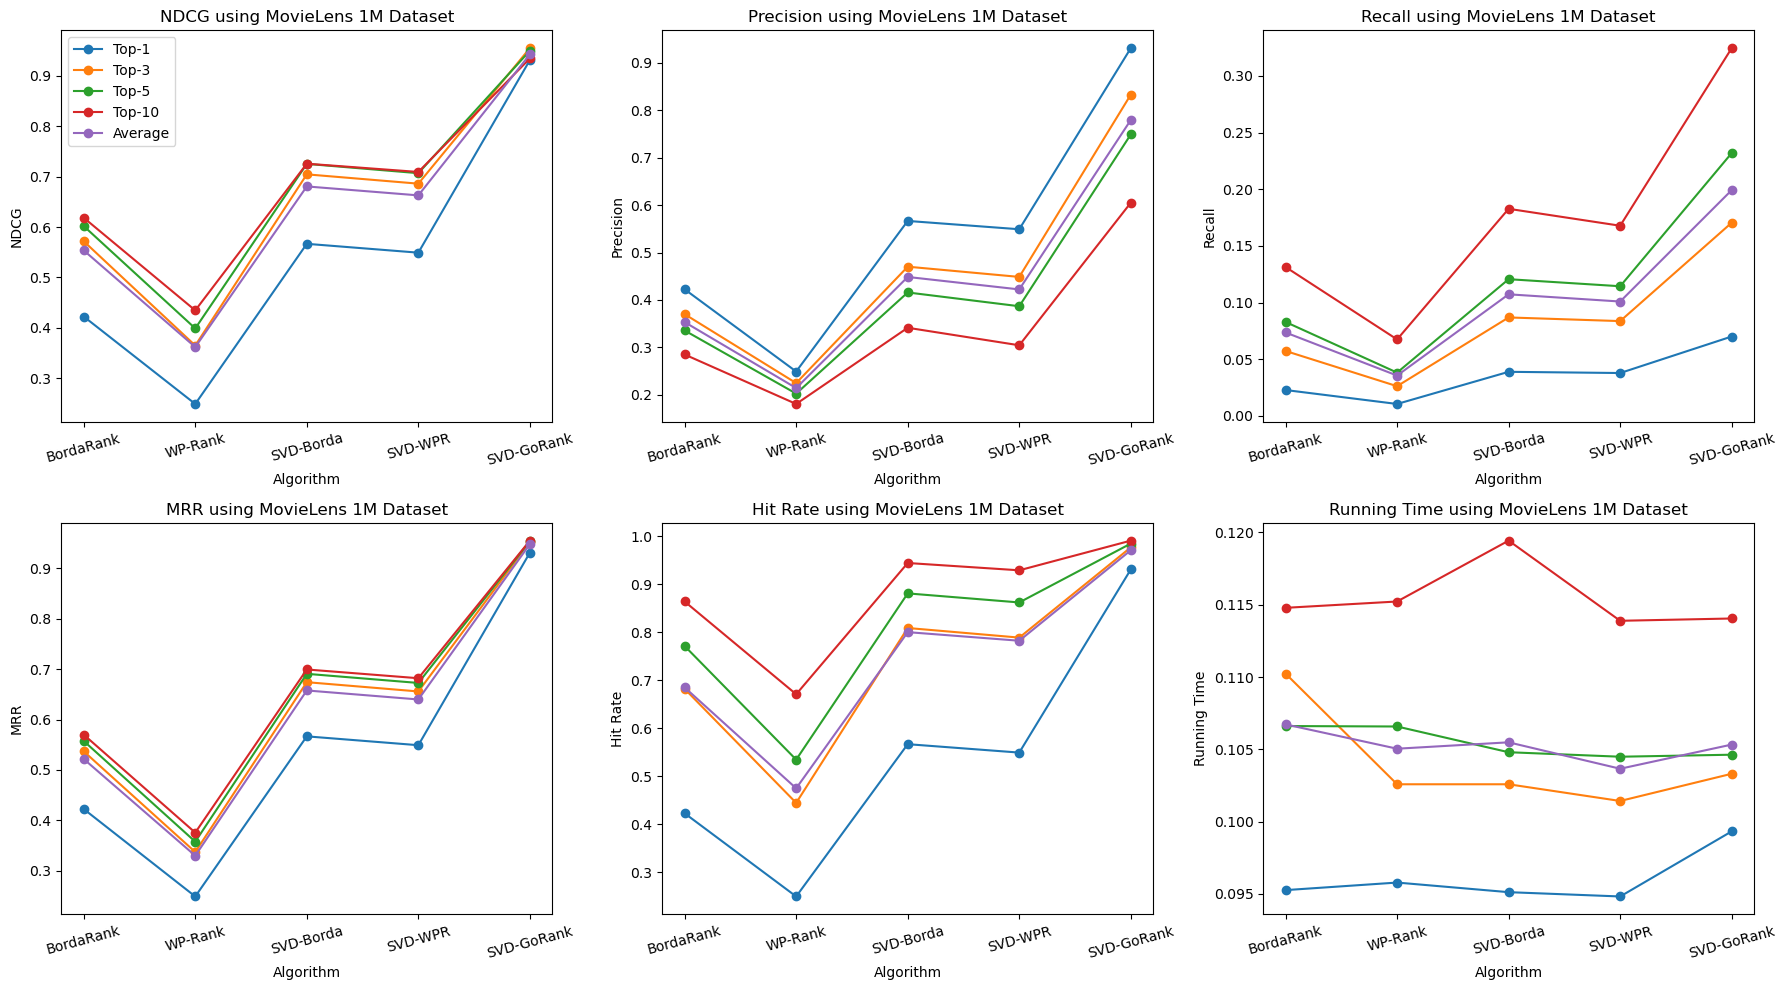

In [75]:
plot_six_metrics(results_ml, "MovieLens 1M Dataset")

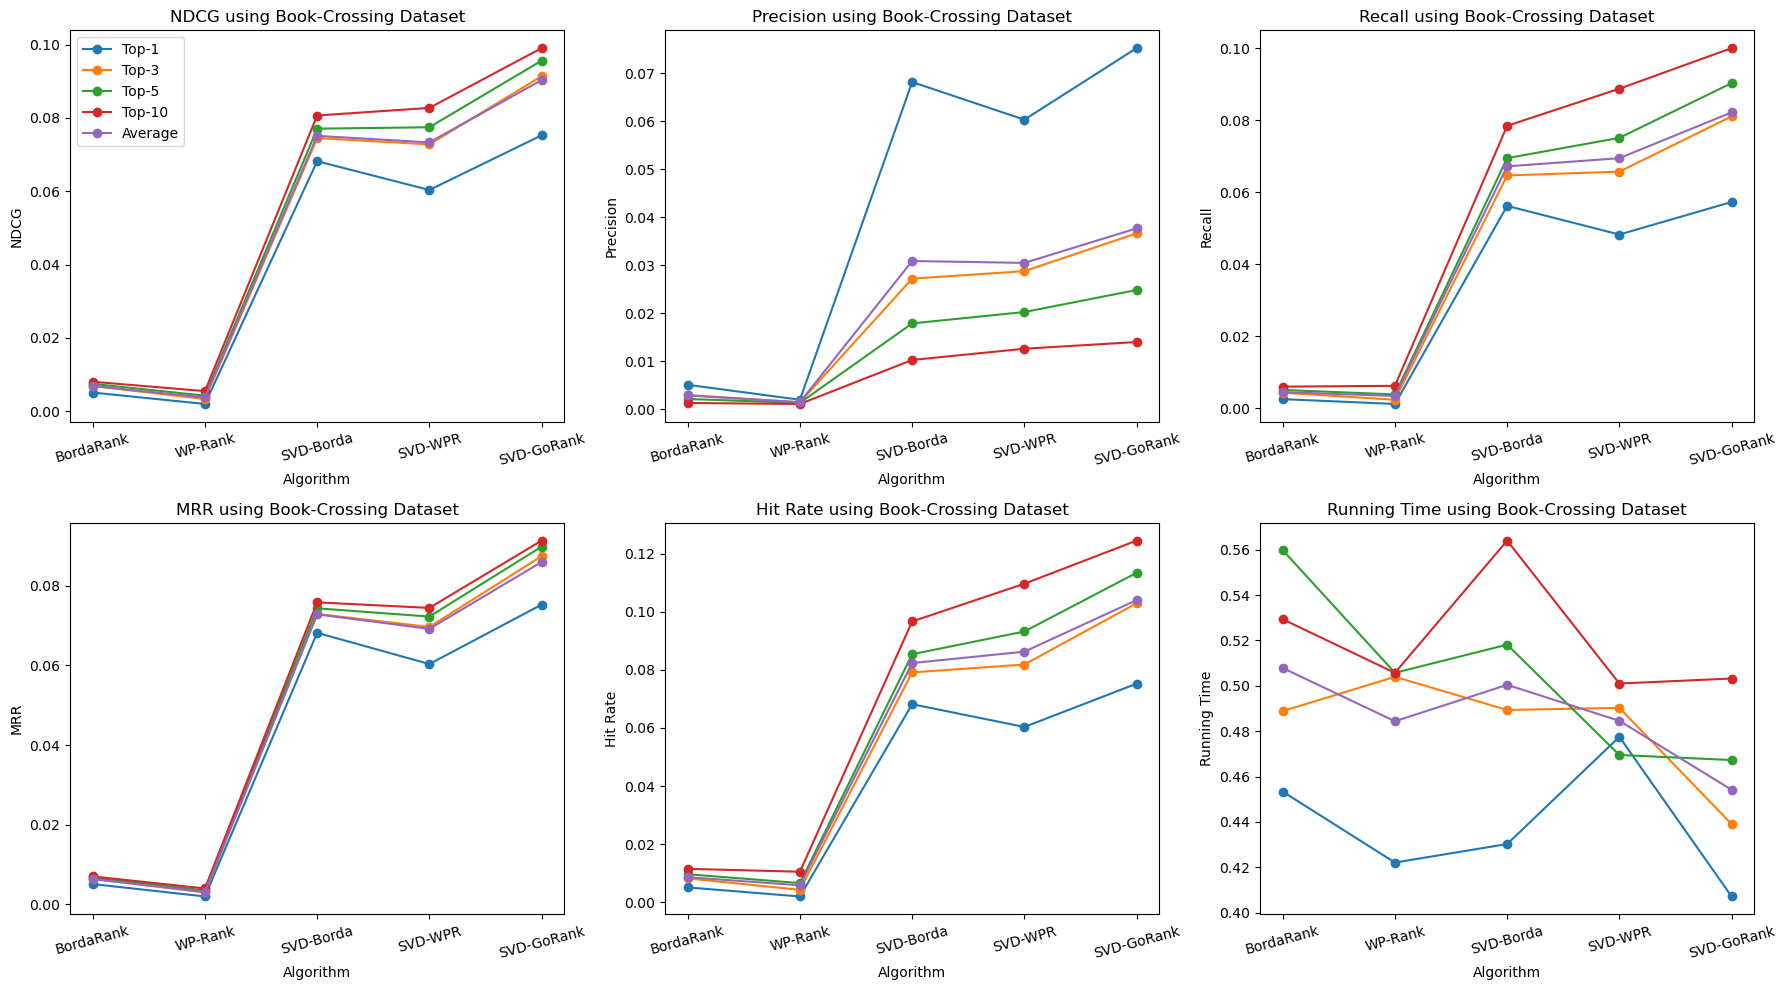

In [76]:
plot_six_metrics(results_bc, "Book-Crossing Dataset")

## ***Inference:***
## The above plots visually confirms that SVD-GoRank is the most stable and accurate algorithm across all metrics and both datasets.

## Comparison of evaluation matrix results

In [97]:
def avg_topk(d):
    return np.mean([d[k] for k in sorted(d.keys())]) # average metric across top-k values

def comparison_table(dataset_info):
    """
    dataset_info = {
        "MovieLens":   (rating_matrix_ml, results_ml),
        "BookCrossing":(rating_matrix_bc, results_bc)
    }
    """
    rows = []  # list to collect rows

    for name, (R, results) in dataset_info.items(): # iterate over dataset name and data
        g = results["SVD-GoRank"] # extract SVD-GoRank results
        row = {
            "Dataset": name, # dataset name
            "Sparsity (%)": (1 - R.count_nonzero()/(R.shape[0]*R.shape[1])) * 100, # compute sparsity (% of zeros)
            # compute averaged metrics for all top-k
            "NDCG":     avg_topk({k: g[k]["NDCG"]   for k in g}),
            "Precision":avg_topk({k: g[k]["PREC"]   for k in g}),
            "Recall":   avg_topk({k: g[k]["RECALL"] for k in g}),
            "MRR":      avg_topk({k: g[k]["MRR"]    for k in g}),
            "Hit Rate": avg_topk({k: g[k]["HR"]     for k in g}),
            "Running Time": avg_topk({k: g[k]["TIME"] for k in g}),
        }
        rows.append(row) # append final row

    return pd.DataFrame(rows) # return a clean table

In [105]:
table = comparison_table({
    "MovieLens":   (rating_matrix_ml, results_ml),
    "BookCrossing":(rating_matrix_bc, results_bc)
})
table

,Dataset,Sparsity (%),NDCG,Precision,Recall,MRR,Hit Rate,Running Time
0,MovieLens,95.531637,0.942667,0.779734,0.199209,0.948268,0.971316,0.105329
1,BookCrossing,99.996238,0.090299,0.037681,0.082214,0.085938,0.104008,0.454168


## ***Inference:***
## The above table clearly shows that dataset sparsity is the strongest factor influencing recommendation performance.
## In MovieLens, where interactions are richer, SVD-GoRank achieves excellent accuracy across all metrics.
## In Book-Crossing, due to extreme sparsity, the algorithm struggles, resulting in very low ranking and prediction metrics.

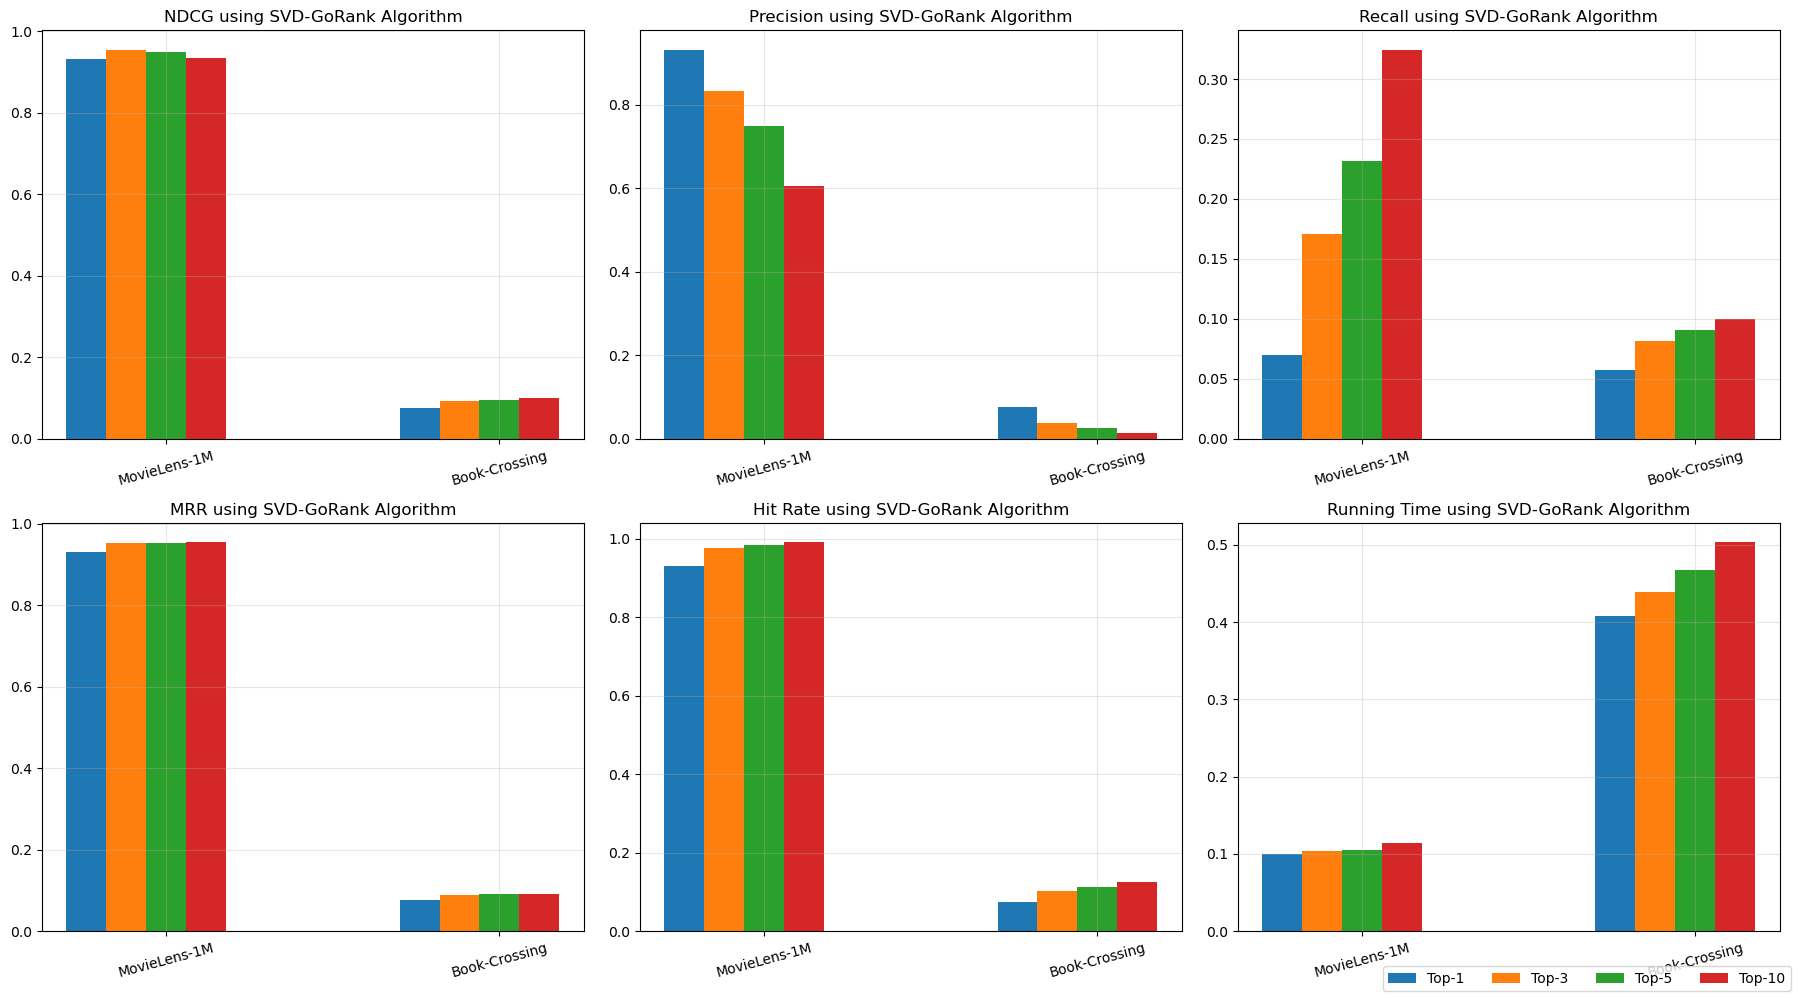

In [112]:
# Extract only SVD-GoRank
svd_ml = results_ml["SVD-GoRank"] # SVD-GoRank metrics for ML
svd_bc = results_bc["SVD-GoRank"] # SVD-GoRank metrics for BC

datasets = ["MovieLens-1M", "Book-Crossing"]

# Convert results into clean table for each metric
def metric_table(metric):
    rows = [] # list to store rows
    for name, svd in zip(datasets, [svd_ml, svd_bc]):
        d = {
            "Dataset": name,
            "Top-1":   svd[1][metric],
            "Top-3":   svd[3][metric],
            "Top-5":   svd[5][metric],
            "Top-10":  svd[10][metric],
        }
        # average of the 4 top-k values
        d["Average"] = np.mean([d["Top-1"], d["Top-3"], d["Top-5"], d["Top-10"]])
        rows.append(d # append row
    return pd.DataFrame(rows) # return table

# Map metric key and title for subplots
metrics = {
    "NDCG": "NDCG using SVD-GoRank Algorithm",
    "PREC": "Precision using SVD-GoRank Algorithm",
    "RECALL": "Recall using SVD-GoRank Algorithm",
    "MRR": "MRR using SVD-GoRank Algorithm",
    "HR": "Hit Rate using SVD-GoRank Algorithm",
    "TIME": "Running Time using SVD-GoRank Algorithm"
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10)) # 6 plots
axes = axes.flatten() # flatten 2×3 grid

for ax, (metric, title) in zip(axes, metrics.items()): # iterate over each metric
    df = metric_table(metric) # table for this metric

    x = np.arange(len(df))  # dataset positions
    width = 0.12 # bar width

    ax.bar(x - 2*width, df["Top-1"],   width, label="Top-1")
    ax.bar(x - width,   df["Top-3"],   width, label="Top-3")
    ax.bar(x,           df["Top-5"],   width, label="Top-5")
    ax.bar(x + width,   df["Top-10"],  width, label="Top-10")

    ax.set_xticks(x) # set xticks
    ax.set_xticklabels(df["Dataset"], rotation=15) # rotate xticks for better readability
    ax.set_title(title) # metric title
    ax.grid(alpha=0.3) # light grid

# Show legend only once
handles, labels = ax.get_legend_handles_labels() # extract last subplot's legend
fig.legend(handles, labels, loc="lower right", ncol=4) # global legend

plt.tight_layout() # adjust figure size to prevent overlap
plt.show() # display the plots

## ***Inference:***
## The above plot highlights that:
- ## SVD-GoRank adapts well in both dense and sparse settings.
- ## It provides excellent Top-K ranking quality, especially on MovieLens.
- ## Even when dataset quality drops, SVD-GoRank retains relative superiority, proving it is the most reliable model among all variants

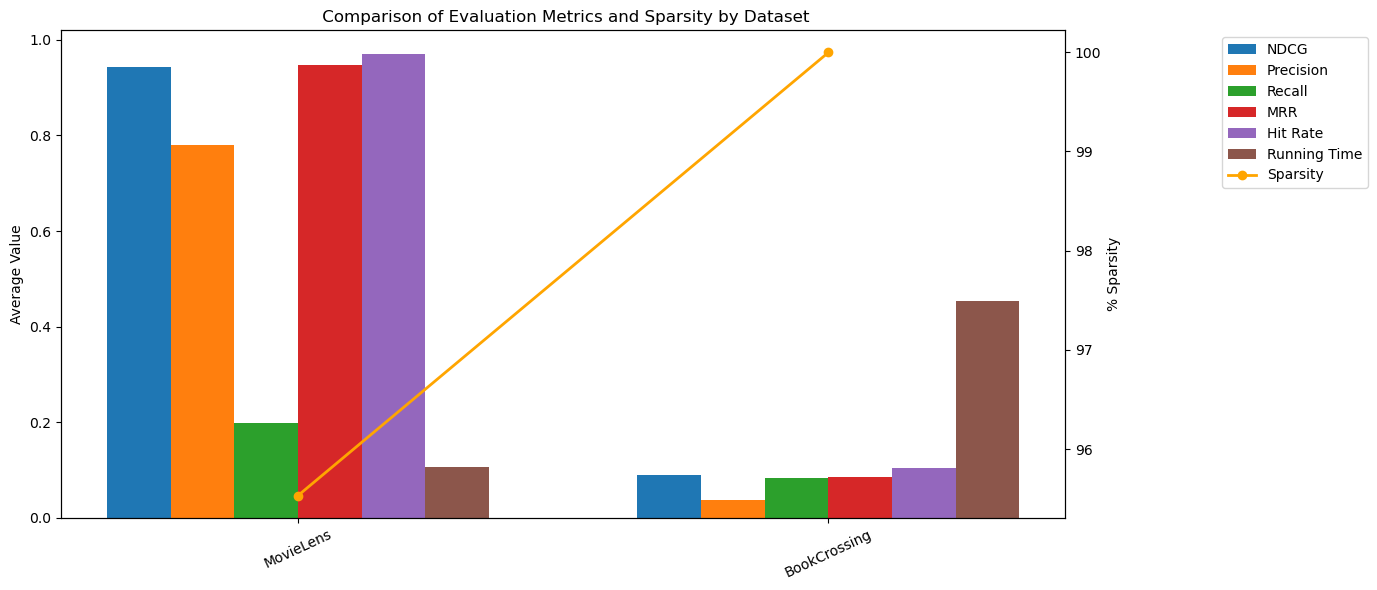

In [106]:
# List the metrics value
ndcg       = table["NDCG"].tolist()
precision  = table["Precision"].tolist()
recall     = table["Recall"].tolist()
mrr        = table["MRR"].tolist()
hr         = table["Hit Rate"].tolist()
runtime    = table["Running Time"].tolist()
sparsity   = table["Sparsity (%)"].tolist()   

metrics_data = [ndcg, precision, recall, mrr, hr, runtime] # group metrics
metric_names = ["NDCG", "Precision", "Recall", "MRR", "Hit Rate", "Running Time"]

# Plot 
x = np.arange(len(datasets)) # dataset positions
width = 0.12 # bar width

fig, ax1 = plt.subplots(figsize=(14,6)) # main plot

# Bars for metrics
for i, (vals, name) in enumerate(zip(metrics_data, metric_names)):
    ax1.bar(x + (i-2.5)*width, vals, width, label=name) # shifted bars

ax1.set_ylabel("Average Value")
ax1.set_title(" Comparison of Evaluation Metrics and Sparsity by Dataset")
ax1.set_xticks(x)
ax1.set_xticklabels(datasets, rotation=25)

#  Sparsity line
ax2 = ax1.twinx()
ax2.plot(x, sparsity, marker="o", color="orange", linewidth=2, label="Sparsity") # sparsity trend line
ax2.set_ylabel("% Sparsity") 
ax2.tick_params(axis='y')

# Legend 
lines_labels = [ax.get_legend_handles_labels() for ax in [ax1, ax2]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
ax1.legend(lines, labels, bbox_to_anchor=(1.15, 1), loc="upper left")

plt.tight_layout() # adjust figure size to prevent overlap
plt.show() # display the plot

## ***Inference:***
## The above plot  clearly demonstrates the direct relationship between sparsity and recommender performance:
- ## Low sparsity (MovieLens) -> high accuracy
- ## High sparsity (Book-Crossing) -> low accuracy
## It visually validates why MovieLens results outperform Book-Crossing in every metric and reiterates that dataset quality strongly influences model performance, even for strong models like SVD-GoRank.

- # ***CONCLUSION:***

## The project concludes that ***SVD-GoRank is a superior and highly robust solution for ranking-based recommendation systems***, consistently outperforming BordaRank, WP-Rank, and other SVD-based hybrids across all evaluation metrics. ***SVD contributes strong latent factor learning***, enabling the model to understand hidden user preferences, while ***GoRank enhances ranking precision by leveraging similarity-driven weighted aggregation***. 
## This hybrid structure proves especially powerful on ***datasets with moderate sparsity, such as MovieLens***, where ***SVD-GoRank achieves exceptionally high NDCG, Precision, Recall, and Hit Rate values***. However, the results also reveal a critical insight: ***extreme data sparsity, as seen in the Book-Crossing dataset***, significantly ***impacts overall performance***, even for advanced hybrid models. Despite this challenge,    ***SVD-GoRank remains the most stable and accurate among all evaluated algorithm***, reinforcing its reliability in real-world scenarios. 
## Overall, this project validates ***SVD-GoRank*** as a ***highly effective, adaptable, and robust recommendation strategy***. 